In [1]:
from models.factory import ModelFactory

model_wrapper = ModelFactory.create(
    model_type="multimode_coconut",
    model_path=r"checkpoints/llama32-1b_gsm_multimode/checkpoint_10",
    device="cuda",
    model_id=r"D:/Researches/InterpreteJLens/base_models/Llama-3.2-1B-Instruct",
)

Registered model type: 'cot' -> CoTModel
Registered model type: 'coconut' -> CoconutModel
Registered model type: 'codi' -> CODIModel
Registered model type: 'no_cot' -> NoCotModel
Registered model type: 'multimode_codi' -> MultimodeCODIModel
Registered model type: 'multimode_coconut' -> MultimodeCoconutModel
Loading Multi-mode Coconut model from D:/Researches/InterpreteJLens/base_models/Llama-3.2-1B-Instruct...


The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Loading checkpoint from checkpoints/llama32-1b_gsm_multimode/checkpoint_10...
Loaded (missing: 0, unexpected: 0)
Multi-mode Coconut model loaded and ready


## Loadings

In [2]:
from pathlib import Path
import jlens
import torch

# ============================================================
# Load the NEW WikiText-calibrated J-lens
# ============================================================

OUT = Path(r"D:\Researches\InterpreteJLens\jlens_outputs")

LENS_PATH = OUT / "coconut_jlens_wikitext103_1000.pt"

# Coconut's actual Llama model
coconut_hf_model = model_wrapper.model.base_causallm
tokenizer = model_wrapper.tokenizer

# J-lens model wrapper
coconut_lens_model = jlens.from_hf(
    coconut_hf_model,
    tokenizer,
    compile=False,
)

# IMPORTANT: load the newly fitted lens
coconut_lens = jlens.JacobianLens.load(
    str(LENS_PATH)
)

print(coconut_lens)
print("n_prompts:", coconut_lens.n_prompts)
print("source_layers:", coconut_lens.source_layers)
print("d_model:", coconut_lens.d_model)

JacobianLens(d_model=2048, n_prompts=1000, source_layers=[0..14] (15 layers))
n_prompts: 1000
source_layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
d_model: 2048


In [3]:
import json
from pathlib import Path
from pprint import pprint

path = Path(r"D:\Researches\InterpreteJLens\data\gsm_valid-gold-reasoning-trace_test.json")

with open(path, "r", encoding="utf-8") as f:
    data = json.load(f)

print("num samples:", len(data))
print("type:", type(data))
print("keys of first sample:")
print(data[0].keys())
print("\nfirst sample:")
pprint(data[0])

num samples: 1194
type: <class 'list'>
keys of first sample:
dict_keys(['question', 'steps', 'answer', 'gen_solutions'])

first sample:
{'answer': '18',
 'gen_solutions': [['<<16-(3+4)=9>>', '<<9*2=18>>'],
                   ['<<3+4=7>>', '<<(16-7)*2=18>>'],
                   ['<<16-3=13>>', '<<(13-4)*2=18>>'],
                   ['<<16-4=12>>', '<<(12-3)*2=18>>'],
                   ['<<2*16=32>>', '<<32-2*3-2*4=18>>'],
                   ['<<16-(4+3)=9>>', '<<2*9=18>>']],
 'question': 'Janet’s ducks lay 16 eggs per day. She eats three for breakfast '
             'every morning and bakes muffins for her friends every day with '
             "four. She sells the remainder at the farmers' market daily for "
             '$2 per fresh duck egg. How much in dollars does she make every '
             "day at the farmers' market?",
 'steps': ['<<16-3-4=9>>', '<<9*2=18>>']}


## visibility and specificity

In [4]:
import torch
from collections import defaultdict

base_model = model_wrapper.model.base_causallm
layers = base_model.model.layers

def run_and_trace(model_wrapper, question, mode, max_new_tokens=40, num_latents=6):
    """
    Run one multimode Coconut inference and record the residual stream
    after every Llama block, for every base-model forward call.
    """

    traces = defaultdict(list)
    handles = []

    # hook each transformer layer
    for layer_idx, layer in enumerate(layers):

        def make_hook(idx):
            def hook(module, inputs, output):
                # LlamaDecoderLayer normally returns tuple;
                # first element is hidden states [B, seq, d_model]
                h = output[0] if isinstance(output, tuple) else output

                # Save the final position from this forward call
                traces[idx].append(
                    h[:, -1, :].detach().float().cpu()
                )

            return hook

        handles.append(
            layer.register_forward_hook(make_hook(layer_idx))
        )

    try:
        prepared = model_wrapper.prepare_input(
            question,
            mode=mode,
            num_latents=num_latents,
        )

        result = model_wrapper.generate(
            input_ids=prepared["input_ids"],
            attention_mask=prepared["attention_mask"],
            mode=mode,
            max_new_tokens=max_new_tokens,
            num_iterations=num_latents,
        )

    finally:
        for h in handles:
            h.remove()

    output_ids = result.output_ids
    decoded = model_wrapper.decode(
        output_ids,
        skip_special_tokens=False
    )

    # Convert:
    # traces[layer][forward_call]
    # ->
    # trace_tensor[forward_call, layer, d_model]
    n_calls = len(traces[0])

    trace_tensor = torch.stack([
        torch.stack(
            [traces[layer][call][0] for layer in range(len(layers))],
            dim=0
        )
        for call in range(n_calls)
    ], dim=0)

    return {
        "mode": mode,
        "output_ids": output_ids,
        "decoded": decoded,
        "trace": trace_tensor,
        "n_calls": n_calls,
        "prepared": prepared,
    }

In [5]:
import ast
import re
from decimal import Decimal, InvalidOperation
from pathlib import Path
import numpy as np
import pandas as pd
import torch

NUM_LATENTS = 6
MAX_NEW_TOKENS = 80

# 先跑少量题检查流程；设为 None 则扫描全部 data。
MAX_SCAN = 50
# MAX_SCAN = None

# 延续你原实验选用的层。
ANALYSIS_LAYERS = [
    layer for layer in coconut_lens.source_layers
    if layer in coconut_lens.source_layers
]

if not ANALYSIS_LAYERS:
    raise ValueError("The fitted lens has no layers in 10–14.")

if not callable(run_and_trace):
    raise ValueError("Run the cell defining run_and_trace first.")

OUT = Path(r"D:\Researches\InterpreteJLens\jlens_outputs")
OUT.mkdir(parents=True, exist_ok=True)

NUMBER_RE = re.compile(r"[-+]?\d[\d,]*(?:\.\d+)?")


def normalize_number(value):
    """Return a canonical numeric string, or None."""
    if value is None:
        return None

    text = str(value).strip().replace(",", "")

    try:
        number = Decimal(text)
    except InvalidOperation:
        return None

    if not number.is_finite():
        return None

    if number == 0:
        return "0"

    return format(number.normalize(), "f")


def last_number(text):
    matches = NUMBER_RE.findall(str(text))
    if not matches:
        return None
    return normalize_number(matches[-1])


def gold_answer_of(sample):
    # Handles both numeric answers and GSM8K-style rationale ending in #### N.
    answer = sample["answer"]
    return normalize_number(answer) or last_number(answer)


def output_correct(result, gold_answer):
    return last_number(result["decoded"]) == gold_answer


def one_token_id(value):
    ids = tokenizer.encode(str(value), add_special_tokens=False)
    return ids[0] if len(ids) == 1 else None


def generated_alignment(result):
    """
    Align the generated text with trace steps using the convention
    used in your original notebook.
    """
    n_steps = result["trace"].shape[0]
    output_ids = result["output_ids"]

    if torch.is_tensor(output_ids):
        output_ids = output_ids.detach().cpu()
        if output_ids.ndim > 1:
            output_ids = output_ids[0]
        output_ids = output_ids.tolist()
    else:
        output_ids = list(output_ids)

    if len(output_ids) < n_steps:
        raise ValueError(
            f"output_ids has {len(output_ids)} tokens, "
            f"but trace has {n_steps} steps."
        )

    ids = output_ids[-n_steps:]

    def decode(token_ids):
        return tokenizer.decode(
            token_ids,
            skip_special_tokens=False,
            clean_up_tokenization_spaces=False,
        )

    text = decode(ids)
    boundaries = [
        len(decode(ids[:k]))
        for k in range(len(ids) + 1)
    ]
    token_texts = [decode([token_id]) for token_id in ids]

    return text, boundaries, token_texts


def char_to_step(char_index, boundaries):
    for step in range(len(boundaries) - 1):
        if boundaries[step] <= char_index < boundaries[step + 1]:
            return step
    return None


def arithmetic_value(expression):
    """Evaluate only basic arithmetic appearing inside <<...>>."""
    expression = expression.replace("×", "*").replace("÷", "/")
    tree = ast.parse(expression, mode="eval")

    def visit(node):
        if isinstance(node, ast.Expression):
            return visit(node.body)

        if isinstance(node, ast.Constant) and type(node.value) in (int, float):
            return Decimal(str(node.value))

        if isinstance(node, ast.UnaryOp):
            value = visit(node.operand)
            if isinstance(node.op, ast.UAdd):
                return value
            if isinstance(node.op, ast.USub):
                return -value

        if isinstance(node, ast.BinOp):
            left = visit(node.left)
            right = visit(node.right)

            if isinstance(node.op, ast.Add):
                return left + right
            if isinstance(node.op, ast.Sub):
                return left - right
            if isinstance(node.op, ast.Mult):
                return left * right
            if isinstance(node.op, ast.Div):
                return left / right

        raise ValueError("Unsupported arithmetic expression")

    return visit(tree)

def extract_intermediates(cot_result):
    """
    Extract valid single-token intermediate numerical results Z
    from the model's ACTUAL generated CoT.

    IMPORTANT TRACE SEMANTICS
    -------------------------
    trace[t] is the hidden state AFTER generated token t
    has entered the context, and it predicts token t+1.

    Therefore, if Z itself is generated at token step z_token_step:

        emission_step = z_token_step - 1
            hidden state that predicts / emits Z

        written_step = z_token_step
            first hidden state where Z is already present
            in the textual CoT context

    For each Z we preserve:

        first_step
            legacy alias for z_token_step

        z_token_step
            token-aligned step where Z itself appears

        emission_step
            state immediately before Z, which predicts Z

        written_step
            first state after Z has entered the chain

        after_write_step
            alias for written_step for compatibility

        post_write_steps
            states beginning immediately with Z in context,
            and ending before the state that predicts the next
            intermediate result
    """

    text, boundaries, token_texts = (
        generated_alignment(cot_result)
    )

    equations = []

    for match in re.finditer(
        r"<<(.*?)>>",
        text,
        flags=re.DOTALL,
    ):

        body = match.group(1)

        if "=" not in body:
            continue

        equal_pos = body.rfind("=")

        lhs = body[
            :equal_pos
        ].strip()

        rhs_part = body[
            equal_pos + 1:
        ]

        rhs_text = (
            rhs_part.strip()
        )

        Z = normalize_number(
            rhs_text
        )

        # Current experiment only keeps one-token Z.
        if (
            Z is None
            or one_token_id(Z) is None
        ):
            continue

        try:

            computed = (
                arithmetic_value(lhs)
            )

            if (
                computed
                != Decimal(Z)
            ):
                continue

        except (
            ValueError,
            InvalidOperation,
            ZeroDivisionError,
            SyntaxError,
        ):
            continue


        # ====================================================
        # Character span of Z in generated CoT
        # ====================================================

        rhs_start = (
            match.start(1)
            + equal_pos
            + 1
            + len(rhs_part)
            - len(
                rhs_part.lstrip()
            )
        )

        rhs_end = (
            rhs_start
            + len(rhs_text)
        )


        # ====================================================
        # Token-aligned Z location
        # ====================================================

        first_step = (
            char_to_step(
                rhs_start,
                boundaries,
            )
        )

        last_step = (
            char_to_step(
                rhs_end - 1,
                boundaries,
            )
        )

        if (
            first_step is None
            or last_step is None
        ):
            continue


        # Current Z is guaranteed to be one tokenizer token,
        # so normally:
        #
        #     first_step == last_step
        #
        # Keep both definitions nevertheless.
        z_token_step = int(first_step)
        z_last_token_step = int(last_step)

        # Require Z to occupy exactly one token in the ACTUAL generated sequence.
        if z_token_step != z_last_token_step:
            continue

        # Also verify that this generated token actually corresponds to Z.
        if normalize_number(token_texts[z_token_step].strip()) != Z:
            continue

        emission_step = z_token_step - 1
        if emission_step < 0:
            continue

        written_step = z_token_step


        equations.append({

            "Z":
                Z,

            "expression":
                body,

            # -----------------------------------------------
            # Token location
            # -----------------------------------------------

            # Keep for compatibility with old code.
            "first_step":
                z_token_step,

            "last_step":
                z_last_token_step,

            "z_token_step":
                z_token_step,

            # -----------------------------------------------
            # Mechanistically meaningful states
            # -----------------------------------------------

            "emission_step":
                emission_step,

            "written_step":
                written_step,

            # Compatibility alias.
            #
            # IMPORTANT:
            # This now means:
            # "first hidden state after Z has been written",
            # not "token after Z".
            "after_write_step":
                written_step,
        })


    # Final equation produces the final answer,
    # not an intermediate Z.
    if len(equations) < 2:
        return []


    intermediates = []


    for current, following in zip(
        equations[:-1],
        equations[1:],
    ):

        # ====================================================
        # Correct post-write interval
        #
        # Start:
        #   state where current Z has just entered context.
        #
        # Stop:
        #   BEFORE the state that predicts the next Z.
        # ====================================================

        post_write_steps = list(
            range(
                current[
                    "written_step"
                ],
                following[
                    "emission_step"
                ],
            )
        )


        if not post_write_steps:
            continue


        intermediates.append({

            "Z":
                current["Z"],

            "expression":
                current["expression"],


            # =================================================
            # Legacy / token-aligned fields
            # =================================================

            "first_step":
                current[
                    "first_step"
                ],

            "last_step":
                current[
                    "last_step"
                ],

            "z_token_step":
                current[
                    "z_token_step"
                ],


            # =================================================
            # Correct mechanistic anchors
            # =================================================

            # State predicting Z
            "emission_step":
                current[
                    "emission_step"
                ],

            # First state with Z already in context
            "written_step":
                current[
                    "written_step"
                ],

            # Compatibility alias
            "after_write_step":
                current[
                    "written_step"
                ],


            # =================================================
            # Correct broad post-externalization interval
            # =================================================

            "post_write_steps":
                post_write_steps,


            # =================================================
            # Next intermediate anchors
            # =================================================

            "next_first_step":
                following[
                    "first_step"
                ],

            "next_emission_step":
                following[
                    "emission_step"
                ],
        })


    return intermediates

In [6]:
def visibility_trajectory(trace, Z):
    """
    Returns one visibility value per trace step.
    Each step averages V(Z) over ANALYSIS_LAYERS.
    """
    token_id = one_token_id(Z)
    if token_id is None:
        return None

    trace = torch.as_tensor(trace)

    if trace.ndim != 3:
        raise ValueError(
            f"Expected trace [step, layer, hidden], got {tuple(trace.shape)}"
        )

    if max(ANALYSIS_LAYERS) >= trace.shape[1]:
        raise ValueError(
            "ANALYSIS_LAYERS exceed the layer dimension of trace."
        )

    device = next(coconut_hf_model.parameters()).device
    n_steps = trace.shape[0]
    by_layer = []

    with torch.no_grad():
        for layer in ANALYSIS_LAYERS:
            layer_values = []

            # Small batches avoid keeping the full
            # [steps, vocabulary] readout in GPU memory.
            for start in range(0, n_steps, 16):
                end = min(start + 16, n_steps)

                residuals = (
                    trace[start:end, layer]
                    .to(device=device, dtype=torch.float32)
                )

                transported = coconut_lens.transport(
                    residuals,
                    layer=layer,
                )

                logits = coconut_lens_model.unembed(
                    transported
                ).float()

                target_logits = logits[:, token_id]

                ranks = (
                    (logits > target_logits[:, None])
                    .sum(dim=-1)
                    + 1
                )

                values = -torch.log10(ranks.float())
                layer_values.append(values.cpu().numpy())

            by_layer.append(
                np.concatenate(layer_values)
            )

    return np.mean(
        np.stack(by_layer, axis=0),
        axis=0,
    )

def specificity_at_steps(
    trace,
    Z,
    wrong_values,
    steps,
):
    """
    Specificity:

        P[ logit(Z) > logit(Z-) ]

    averaged over:
        matched wrong values
        selected reasoning steps
        ANALYSIS_LAYERS

    Equivalent to:
        P[ rank(Z) < rank(Z-) ]
    """

    steps = [
        int(step)
        for step in steps
        if 0 <= int(step) < trace.shape[0]
    ]

    if not steps or not wrong_values:
        return np.nan

    true_id = one_token_id(Z)

    wrong_ids = [
        one_token_id(value)
        for value in wrong_values
    ]

    if (
        true_id is None
        or any(x is None for x in wrong_ids)
    ):
        return np.nan

    device = next(
        coconut_hf_model.parameters()
    ).device

    trace = torch.as_tensor(trace)

    layer_scores = []

    with torch.no_grad():

        for layer in ANALYSIS_LAYERS:

            step_scores = []

            for start in range(
                0,
                len(steps),
                16,
            ):
                batch_steps = steps[
                    start:start + 16
                ]

                residuals = (
                    trace[
                        batch_steps,
                        layer,
                    ]
                    .to(
                        device=device,
                        dtype=torch.float32,
                    )
                )

                transported = (
                    coconut_lens.transport(
                        residuals,
                        layer=layer,
                    )
                )

                logits = (
                    coconut_lens_model
                    .unembed(
                        transported
                    )
                    .float()
                )

                true_logits = (
                    logits[:, true_id]
                )

                wrong_logits = logits[
                    :,
                    wrong_ids,
                ]

                wins = (
                    true_logits[:, None]
                    > wrong_logits
                ).float()

                step_scores.extend(
                    wins.mean(dim=1)
                    .cpu()
                    .tolist()
                )

            layer_scores.append(
                np.mean(
                    step_scores
                )
            )

    return float(
        np.mean(
            layer_scores
        )
    )

def mean_at_steps(trajectory, steps):
    if trajectory is None:
        return np.nan

    valid = [
        trajectory[step]
        for step in steps
        if 0 <= step < len(trajectory)
        and np.isfinite(trajectory[step])
    ]

    return float(np.mean(valid)) if valid else np.nan

def final_answer_prediction_window(
    result,
    gold_answer,
    max_window=5,
):
    """
    Window ending AT the state that predicts the final answer.
    """

    info = final_answer_prediction_info(
        result,
        gold_answer,
    )

    if info is None:
        return None

    anchor = int(
        info[
            "answer_prediction_step"
        ]
    )

    steps = list(
        range(
            max(
                0,
                anchor - max_window + 1,
            ),
            anchor + 1,
        )
    )

    return {
        **info,
        "steps": steps,
        "k": len(steps),
    }

def direct_pre_answer_steps(result, gold_answer):

    text, boundaries, _ = generated_alignment(result)

    answer_matches = [
        match for match in NUMBER_RE.finditer(text)
        if normalize_number(match.group(0)) == gold_answer
    ]

    if not answer_matches:
        return []

    answer_step = char_to_step(
        answer_matches[-1].start(),
        boundaries,
    )

    if answer_step is None:
        return []

    # Preserve the convention of your original direct window.
    return list(range(answer_step)) or [0]

In [8]:
from collections import Counter

import numpy as np
import pandas as pd
import torch

from pathlib import Path

# ============================================================
# 1. Specificity controls
# ============================================================

def matched_wrong_values_all(
    Z,
    forbidden,
):
    """
    Construct all matched numerical alternatives Z-.

    Controls:
      - non-negative integer
      - same number of digits as true Z
      - one tokenizer token
      - not true Z
      - not present in forbidden set

    Using the whole matched pool eliminates
    negative-sampling variance.
    """

    Z = str(Z)

    if not Z.isdigit():
        return []

    if str(int(Z)) != Z:
        return []

    n_digits = len(Z)

    lower = (
        0
        if n_digits == 1
        else 10 ** (n_digits - 1)
    )

    upper = (
        10 ** n_digits
    )

    # Current experiment:
    # only <= 3-digit intermediates.
    if upper > 1000:
        return []

    candidates = []

    for number in range(
        lower,
        upper,
    ):

        value = str(
            number
        )

        if value == Z:
            continue

        if value in forbidden:
            continue

        if one_token_id(
            value
        ) is None:
            continue

        candidates.append(
            value
        )

    if len(candidates) < MIN_WRONG:
        return []

    return candidates


# ============================================================
# 2. Specificity
# ============================================================

def specificity_at_steps(
    trace,
    Z,
    wrong_values,
    steps,
):
    """
    Specificity:

        P[ logit(Z) > logit(Z-) ]

    averaged over:
        matched wrong values
        selected reasoning states
        ANALYSIS_LAYERS

    Equivalent to:

        P[ rank(Z) < rank(Z-) ]
    """

    steps = [
        int(step)
        for step in steps
        if (
            0 <= int(step)
            < trace.shape[0]
        )
    ]

    if (
        not steps
        or not wrong_values
    ):
        return np.nan

    true_id = one_token_id(
        Z
    )

    wrong_ids = [
        one_token_id(
            value
        )
        for value in wrong_values
    ]

    if (
        true_id is None
        or any(
            x is None
            for x in wrong_ids
        )
    ):
        return np.nan

    device = next(
        coconut_hf_model.parameters()
    ).device

    trace = torch.as_tensor(
        trace
    )

    layer_scores = []

    with torch.no_grad():

        for layer in ANALYSIS_LAYERS:

            step_scores = []

            for start in range(
                0,
                len(steps),
                16,
            ):

                batch_steps = (
                    steps[
                        start:start + 16
                    ]
                )

                residuals = (
                    trace[
                        batch_steps,
                        layer,
                    ]
                    .to(
                        device=device,
                        dtype=torch.float32,
                    )
                )

                transported = (
                    coconut_lens.transport(
                        residuals,
                        layer=layer,
                    )
                )

                logits = (
                    coconut_lens_model
                    .unembed(
                        transported
                    )
                    .float()
                )

                true_logits = (
                    logits[
                        :,
                        true_id
                    ]
                )

                wrong_logits = (
                    logits[
                        :,
                        wrong_ids,
                    ]
                )

                wins = (
                    true_logits[:, None]
                    > wrong_logits
                ).float()

                step_scores.extend(
                    wins.mean(
                        dim=1
                    )
                    .cpu()
                    .tolist()
                )

            layer_scores.append(
                np.mean(
                    step_scores
                )
            )

    return float(
        np.mean(
            layer_scores
        )
    )


# ============================================================
# 3. Locate final-answer prediction state
# ============================================================

def final_answer_prediction_info(
    result,
    gold_answer,
):
    """
    Locate the state predicting the FIRST token of the
    final occurrence of the gold numerical answer.

    Verified trace semantics:

        trace[t]
            = state after aligned token t is in context
            = state predicting aligned token t+1

    Therefore:

        answer_prediction_step
            = answer_token_step - 1
    """

    text, boundaries, token_texts = (
        generated_alignment(
            result
        )
    )

    answer_matches = [
        match
        for match in NUMBER_RE.finditer(
            text
        )
        if normalize_number(
            match.group(0)
        ) == gold_answer
    ]

    if not answer_matches:
        return None

    # Final occurrence of gold answer.
    match = (
        answer_matches[-1]
    )

    answer_token_step = (
        char_to_step(
            match.start(),
            boundaries,
        )
    )

    if answer_token_step is None:
        return None

    answer_token_step = int(
        answer_token_step
    )

    answer_prediction_step = (
        answer_token_step - 1
    )

    # If final answer is literally the first generated token,
    # the prediction state lies before our generated-token trace.
    if not (
        0
        <= answer_prediction_step
        < result[
            "trace"
        ].shape[0]
    ):
        return None

    return {
        "answer_token_step":
            answer_token_step,

        "answer_prediction_step":
            answer_prediction_step,

        "answer_text":
            match.group(0),

        "prediction_state_token":
            token_texts[
                answer_prediction_step
            ],

        "answer_first_token":
            token_texts[
                answer_token_step
            ],
    }


# ============================================================
# 4. Shared endpoint windows
# ============================================================

def canonical_answer_windows(
    direct_result,
    cot_result,
    gold_answer,
    max_window=5,
):
    """
    Build matched endpoint windows.

    Both modes are aligned to exactly the same event:

        state predicting final answer Y

    Anchor:
        exact answer-prediction state

    Window:
        final matched k states ending at that anchor
    """

    direct_info = (
        final_answer_prediction_info(
            direct_result,
            gold_answer,
        )
    )

    cot_info = (
        final_answer_prediction_info(
            cot_result,
            gold_answer,
        )
    )

    if (
        direct_info is None
        or cot_info is None
    ):
        return None

    direct_anchor = int(
        direct_info[
            "answer_prediction_step"
        ]
    )

    cot_anchor = int(
        cot_info[
            "answer_prediction_step"
        ]
    )

    direct_available = list(
        range(
            max(
                0,
                direct_anchor
                - max_window
                + 1,
            ),
            direct_anchor + 1,
        )
    )

    cot_available = list(
        range(
            max(
                0,
                cot_anchor
                - max_window
                + 1,
            ),
            cot_anchor + 1,
        )
    )

    k = min(
        max_window,
        len(
            direct_available
        ),
        len(
            cot_available
        ),
    )

    if k < 2:
        return None

    return {
        # Exact endpoint
        "direct_anchor":
            [direct_anchor],

        "cot_anchor":
            [cot_anchor],

        # Matched endpoint windows
        "direct_window":
            direct_available[-k:],

        "cot_window":
            cot_available[-k:],

        "k":
            k,

        "direct_answer_token_step":
            direct_info[
                "answer_token_step"
            ],

        "cot_answer_token_step":
            cot_info[
                "answer_token_step"
            ],
    }


# ============================================================
# 5. PRIMARY retention intervals
# ============================================================

def downstream_retention_steps(
    direct_result,
    cot_result,
    answer_windows,
    info,
):
    """
    Construct intervals for the main substitution hypothesis.

    DIRECT:
        all generated states through final-answer prediction.

        Z cannot be externalized, so we ask how strongly it
        remains represented throughout the available Direct
        trajectory.

    CoT:
        start AFTER the hidden state whose current token is Z,
        then continue through final-answer prediction.

        This asks how strongly Z remains internally represented
        once Z has already been externalized into textual CoT.

    Important:
        written_step itself is excluded because that state's
        current token is literally Z and may contain a trivial
        lexical trace of Z.
    """

    direct_answer_step = int(
        answer_windows[
            "direct_anchor"
        ][0]
    )

    cot_answer_step = int(
        answer_windows[
            "cot_anchor"
        ][0]
    )

    written_step = int(
        info[
            "written_step"
        ]
    )

    # --------------------------------------------------------
    # Direct
    # --------------------------------------------------------

    direct_steps = list(
        range(
            0,
            direct_answer_step + 1,
        )
    )

    # --------------------------------------------------------
    # CoT post-externalization
    #
    # written_step:
    #   state whose current token is literally Z
    #
    # written_step + 1:
    #   first subsequent reasoning state
    # --------------------------------------------------------

    cot_start = (
        written_step + 1
    )

    if (
        cot_start
        > cot_answer_step
    ):
        return None

    cot_steps = list(
        range(
            cot_start,
            cot_answer_step + 1,
        )
    )

    direct_steps = [
        step
        for step in direct_steps
        if (
            0 <= step
            < direct_result[
                "trace"
            ].shape[0]
        )
    ]

    cot_steps = [
        step
        for step in cot_steps
        if (
            0 <= step
            < cot_result[
                "trace"
            ].shape[0]
        )
    ]

    if (
        not direct_steps
        or not cot_steps
    ):
        return None

    return {
        "direct":
            direct_steps,

        "cot":
            cot_steps,

        "n_direct":
            len(
                direct_steps
            ),

        "n_cot":
            len(
                cot_steps
            ),

        "direct_start":
            direct_steps[0],

        "cot_start":
            cot_steps[0],

        "direct_end":
            direct_steps[-1],

        "cot_end":
            cot_steps[-1],
    }




    latent_obs_df.to_csv(
        Path(OUT)
        / "canonical_latent_Z_level.csv",
        index=False,
    )


    latent_sample_df.to_csv(
        Path(OUT)
        / "canonical_latent_problem_level.csv",
        index=False,
    )

In [13]:
# ============================================================
# BLOCK 1: compute per-Z / per-problem / per-layer trajectories
# Run AFTER the original model, lens, extraction/alignment helpers.
# Replaces the old THREE-MODE TRAJECTORY COMPUTATION + run/save cell.
# Does not call visibility_trajectory or specificity_at_steps.
# ============================================================
import json
from collections import Counter
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from IPython.display import display

MAX_SCAN = None                 # None = scan all problems
NUM_LATENTS = 6
MAX_NEW_TOKENS = 80
MAX_LOOKBACK_STEPS = 9
FINAL_TEXT_STEPS = 3
READOUT_BATCH_SIZE = 16
MIN_WRONG = 4 
ANALYSIS_LAYERS = sorted(set(int(l) for l in coconut_lens.source_layers))
GLOBAL_LAYERS = ANALYSIS_LAYERS.copy()  # fixed, equal-weight summary
OUT = Path(globals().get("OUT", r"D:\Researches\InterpreteJLens\jlens_outputs"))
OUT.mkdir(parents=True, exist_ok=True)

# Your existing trace code uses trace[:, layer] for block layer.
# Keep this identity mapping IF trace stores block outputs only.
# If trace includes the embedding as index 0 (HF hidden_states), use l + 1.
# If trace contains only a subset of blocks, supply its actual mapping.
TRACE_LAYER_INDEX = {l: l for l in ANALYSIS_LAYERS}
COMPUTE_LM_REFERENCE = True
# Assumes trace[:, -1] is the final block output BEFORE final norm,
# as in your original actual_lm_visibility implementation.
LM_TRACE_INDEX = -1

_helpers = [
    "run_and_trace", "gold_answer_of", "output_correct", "one_token_id",
    "normalize_number", "extract_intermediates", "matched_wrong_values_all",
    "generated_alignment", "final_answer_prediction_info",
]
_missing = [name for name in _helpers if not callable(globals().get(name))]
if _missing:
    raise RuntimeError("Run the original helper definitions first: " + ", ".join(_missing))
if not ANALYSIS_LAYERS or not GLOBAL_LAYERS:
    raise ValueError("No source layers selected.")
if not set(GLOBAL_LAYERS).issubset(ANALYSIS_LAYERS):
    raise ValueError("GLOBAL_LAYERS must be a subset of ANALYSIS_LAYERS.")
if FINAL_TEXT_STEPS != 3 or MAX_LOOKBACK_STEPS < FINAL_TEXT_STEPS:
    raise ValueError("This block uses three common final textual states.")
print("Lens source layers:", ANALYSIS_LAYERS)
print("Trace indices:", TRACE_LAYER_INDEX)
print("Global average layers:", GLOBAL_LAYERS)

MODES = ("Direct", "CoT", "Latent")
METRICS = ["visibility", "specificity"]
if COMPUTE_LM_REFERENCE:
    METRICS += ["lm_visibility", "readout_gap"]


def _text_positions(result, gold, max_steps, offset=0):
    view = dict(result)
    view["trace"] = result["trace"][offset:]
    info = final_answer_prediction_info(view, gold)
    if info is None:
        return []
    anchor = int(info["answer_prediction_step"])
    n = len(view["trace"])
    if not 0 <= anchor < n:
        return []
    _, _, tokens = generated_alignment(view)
    if len(tokens) != n:
        raise ValueError("Generated-token and trace-step counts disagree.")
    return [
        dict(x=s-anchor, step=s+offset, phase="text", stage=None,
             predicted_token=tokens[s])
        for s in range(max(0, anchor-max_steps+1), anchor+1)
    ]


def _positions_for_modes(results, gold):
    positions = {
        m: _text_positions(results[m], gold, MAX_LOOKBACK_STEPS)
        for m in ("Direct", "CoT")
    }
    text = _text_positions(results["Latent"], gold, FINAL_TEXT_STEPS, NUM_LATENTS)
    start = -(NUM_LATENTS + FINAL_TEXT_STEPS - 1)
    positions["Latent"] = [
        dict(x=start+i, step=i, phase="latent", stage=f"L{i+1}",
             predicted_token=None)
        for i in range(NUM_LATENTS)
    ] + text
    for mode, pp in positions.items():
        # Require a complete final tail in every mode; do not invent missing states.
        text_x = {p["x"] for p in pp if p["phase"] == "text"}
        if not {-2, -1, 0}.issubset(text_x):
            return None
        if len({p["x"] for p in pp}) != len(pp):
            raise ValueError(f"Duplicate x positions in {mode}.")
        if any(p["step"] < 0 or p["step"] >= len(results[mode]["trace"]) for p in pp):
            return None
    return positions


def _forbidden_values(question, cot_result, intermediates, gold):
    # Uses the NUMBER_RE and normalization rules in your original setup.
    cot_text, _, _ = generated_alignment(cot_result)
    forbidden = {gold}
    for text in (question, cot_text):
        forbidden.update(
            v for match in NUMBER_RE.finditer(text)
            if (v := normalize_number(match.group(0))) is not None
        )
    forbidden.update(str(item["Z"]) for item in intermediates)
    return forbidden


@torch.no_grad()
def _measure_all_z(result, positions, z_items, mode):
    """One unembedding per layer/batch, reused for all Z and wrong controls."""
    trace = torch.as_tensor(result["trace"])
    if trace.ndim != 3:
        raise ValueError(f"Expected [step, layer, hidden], got {tuple(trace.shape)}")
    if any(not 0 <= idx < trace.shape[1] for idx in TRACE_LAYER_INDEX.values()):
        raise ValueError("TRACE_LAYER_INDEX does not match the trace layer axis.")
    device = next(coconut_hf_model.parameters()).device
    steps = [int(p["step"]) for p in positions]
    lm_values = {}

    if COMPUTE_LM_REFERENCE:
        for start in range(0, len(steps), READOUT_BATCH_SIZE):
            ss = steps[start:start+READOUT_BATCH_SIZE]
            h = trace[ss, LM_TRACE_INDEX].to(device=device, dtype=torch.float32)
            norm = coconut_hf_model.model.norm
            head = coconut_hf_model.lm_head
            logits = head(norm(h.to(dtype=norm.weight.dtype)).to(dtype=head.weight.dtype)).float()
            if not torch.isfinite(logits).all():
                raise ValueError("Non-finite actual LM-head logits.")
            for item in z_items:
                target = logits[:, item["true_id"]]
                ranks = 1 + (logits > target[:, None]).sum(-1)
                vv = -torch.log10(ranks.float()).cpu().numpy()
                for j, value in enumerate(vv):
                    lm_values[(item["z_idx"], start+j)] = float(value)

    rows = []
    for layer in ANALYSIS_LAYERS:
        for start in range(0, len(steps), READOUT_BATCH_SIZE):
            ss = steps[start:start+READOUT_BATCH_SIZE]
            h = trace[ss, TRACE_LAYER_INDEX[layer]].to(device=device, dtype=torch.float32)
            transported = coconut_lens.transport(h, layer=layer)
            logits = coconut_lens_model.unembed(transported).float()
            if not torch.isfinite(logits).all():
                raise ValueError(f"Non-finite J-Lens logits at layer {layer}.")
            for item in z_items:
                target = logits[:, item["true_id"]]
                ranks = 1 + (logits > target[:, None]).sum(-1)
                visibility = -torch.log10(ranks.float()).cpu().numpy()
                specificity = (
                    target[:, None] > logits[:, item["wrong_ids"]]
                ).float().mean(-1).cpu().numpy()
                for j, (v, spec) in enumerate(zip(visibility, specificity)):
                    p = positions[start+j]
                    row = dict(
                        mode=mode, layer=layer, **p, z_idx=item["z_idx"],
                        Z=item["Z"], n_wrong=len(item["wrong_ids"]),
                        visibility=float(v), specificity=float(spec),
                    )
                    if COMPUTE_LM_REFERENCE:
                        lm = lm_values[(item["z_idx"], start+j)]
                        row.update(lm_visibility=lm, readout_gap=lm-float(v))
                    rows.append(row)
    return rows


def global_from_layers(layer_z_df, layers):
    """Z: mean over layers -> problem: mean over Z. No missing-layer averaging."""
    keys = ["dataset_idx", "z_idx", "Z", "mode", "x", "step", "phase"]
    selected = layer_z_df[layer_z_df["layer"].isin(layers)]
    if selected.empty:
        raise ValueError("No measurements for requested global layers.")
    counts = selected.groupby(keys)["layer"].agg(["size", "nunique"])
    if not ((counts["size"] == len(layers)) & (counts["nunique"] == len(layers))).all():
        raise ValueError("Incomplete or duplicated layer grid; refusing biased averages.")
    z_global = selected.groupby(keys, as_index=False)[METRICS].mean()
    problem_global = z_global.groupby(["dataset_idx", "mode", "x"], as_index=False)[METRICS].mean()
    return z_global, problem_global


def compute_three_mode_layers(data, max_scan=MAX_SCAN):
    rows, audit_rows, controls, status_rows = [], [], [], []
    exclusions = Counter()
    n_scan = len(data) if max_scan is None else min(len(data), max_scan)
    coconut_hf_model.eval()
    for dataset_idx in range(n_scan):
        sample = data[dataset_idx]
        gold = gold_answer_of(sample)
        if gold is None:
            exclusions["no_gold"] += 1
            continue
        question = sample["question"]
        results = {
            mode: run_and_trace(
                model_wrapper, question, mode=run_mode,
                max_new_tokens=MAX_NEW_TOKENS, num_latents=NUM_LATENTS,
            )
            for mode, run_mode in zip(MODES, ("direct", "verbalized", "latent"))
        }
        correct = {mode: bool(output_correct(results[mode], gold)) for mode in MODES}
        status_rows.append(dict(dataset_idx=dataset_idx, gold=gold,
                                **{f"{m}_correct": c for m, c in correct.items()}))
        print(f"\rScanned {dataset_idx+1}/{n_scan}; retained rows={len(rows)}", end="", flush=True)
        if not all(correct.values()):
            for mode, ok in correct.items():
                if not ok:
                    exclusions[f"{mode}_wrong"] += 1
            continue
        intermediates = list(extract_intermediates(results["CoT"]) or [])
        if not intermediates:
            exclusions["no_intermediate"] += 1
            continue
        positions = _positions_for_modes(results, gold)
        if positions is None:
            exclusions["incomplete_final_tail"] += 1
            continue
        forbidden = _forbidden_values(question, results["CoT"], intermediates, gold)
        items = []
        for z_idx, info in enumerate(intermediates):
            Z = str(info["Z"])
            true_id = one_token_id(Z)
            if true_id is None:
                exclusions["Z_not_single_token"] += 1
                continue
            # One identical control set per Z, shared by every mode/layer/state.
            wrong_values = list(matched_wrong_values_all(Z, forbidden=forbidden) or [])
            wrong_ids = [one_token_id(value) for value in wrong_values]
            if not wrong_ids or any(i is None for i in wrong_ids):
                exclusions["invalid_matched_controls"] += 1
                continue
            if true_id in wrong_ids or len(set(wrong_ids)) != len(wrong_ids):
                raise ValueError("Matched controls contain true Z or duplicate token IDs.")
            items.append(dict(z_idx=z_idx, Z=Z, true_id=true_id, wrong_ids=wrong_ids))
            controls.append(dict(dataset_idx=dataset_idx, z_idx=z_idx, Z=Z,
                                 wrong_values=json.dumps([str(v) for v in wrong_values]),
                                 wrong_ids=json.dumps([int(i) for i in wrong_ids])))
        if not items:
            exclusions["no_eligible_Z"] += 1
            continue
        for mode in MODES:
            measured = _measure_all_z(results[mode], positions[mode], items, mode)
            for row in measured:
                row["dataset_idx"] = dataset_idx
            rows.extend(measured)
            audit_rows.extend(dict(dataset_idx=dataset_idx, mode=mode, **p)
                              for p in positions[mode])
        # Traces are not retained across problems, to keep CPU/GPU use bounded.
        del results
    print()
    if not rows:
        raise RuntimeError(f"No usable all-three-correct problems. Exclusions: {dict(exclusions)}")
    layer_z = pd.DataFrame(rows)
    if layer_z.duplicated(["dataset_idx", "z_idx", "mode", "layer", "x"]).any():
        raise ValueError("Duplicate observations in per-layer data.")
    layer_problem = layer_z.groupby(
        ["dataset_idx", "mode", "layer", "x"], as_index=False
    )[METRICS].mean()
    global_z, global_problem = global_from_layers(layer_z, GLOBAL_LAYERS)
    return (layer_z, layer_problem, global_z, global_problem, exclusions,
            pd.DataFrame(audit_rows), pd.DataFrame(controls), pd.DataFrame(status_rows))


(trajectory3_layer_Z_df, trajectory3_layer_problem_df,
 trajectory3_Z_df, trajectory3_problem_df, trajectory3_exclusions,
 trajectory3_alignment_df, trajectory3_controls_df, trajectory3_status_df
) = compute_three_mode_layers(data, MAX_SCAN)

for name, frame in {
    "layer_Z": trajectory3_layer_Z_df,
    "layer_problem": trajectory3_layer_problem_df,
    "global_Z": trajectory3_Z_df,
    "global_problem": trajectory3_problem_df,
    "alignment": trajectory3_alignment_df,
    "controls": trajectory3_controls_df,
    "status": trajectory3_status_df,
}.items():
    frame.to_csv(OUT / f"three_mode_{name}.csv", index=False)
coverage3_df = trajectory3_problem_df.groupby(["x", "mode"])["dataset_idx"].nunique().unstack("mode")
coverage3_df.to_csv(OUT / "three_mode_coverage.csv")
metadata = dict(
    analysis_layers=ANALYSIS_LAYERS, global_layers=GLOBAL_LAYERS,
    trace_layer_index=TRACE_LAYER_INDEX, max_scan=MAX_SCAN,
    num_latents=NUM_LATENTS, max_new_tokens=MAX_NEW_TOKENS,
    max_lookback_steps=MAX_LOOKBACK_STEPS, final_text_steps=FINAL_TEXT_STEPS,
    compute_lm_reference=COMPUTE_LM_REFERENCE, lm_trace_index=LM_TRACE_INDEX,
    selection="all three final answers correct under original output_correct",
    aggregation="equal layers within Z; equal Z within problem; equal problems",
    exclusions=dict(trajectory3_exclusions),
)
(OUT / "three_mode_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Retained problems:", trajectory3_problem_df.dataset_idx.nunique())
print("Retained Z:", len(trajectory3_layer_Z_df[["dataset_idx", "z_idx"]].drop_duplicates()))
print("Exclusions (wrong-mode counts may overlap):", dict(trajectory3_exclusions))
display(coverage3_df)
print("Alignment audit: inspect these BEFORE labeling the last three states Answer / : / Y.")
display(trajectory3_alignment_df.query("phase == 'text' and x >= -2")
        .groupby(["mode", "x", "predicted_token"]).size().rename("n").reset_index())


Lens source layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Trace indices: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 8: 8, 9: 9, 10: 10, 11: 11, 12: 12, 13: 13, 14: 14}
Global average layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Scanned 1194/1194; retained rows=131985
Retained problems: 263
Retained Z: 420
Exclusions (wrong-mode counts may overlap): {'Direct_wrong': 835, 'CoT_wrong': 466, 'Latent_wrong': 826, 'invalid_matched_controls': 3, 'no_eligible_Z': 1, 'no_intermediate': 35}


mode,CoT,Direct,Latent
x,,,
-8,263.0,NaN,263.0
-7,263.0,NaN,263.0
-6,263.0,NaN,263.0
-5,263.0,NaN,263.0
-4,263.0,NaN,263.0
-3,263.0,NaN,263.0
-2,263.0,263.0,263.0
-1,263.0,263.0,263.0
0,263.0,263.0,263.0


Alignment audit: inspect these BEFORE labeling the last three states Answer / : / Y.


,mode,x,predicted_token,n
0,CoT,-2,<|eocot|>,263
1,CoT,-1,###,263
2,CoT,0,,263
3,Direct,-2,<|eocot|>,263
4,Direct,-1,###,263
5,Direct,0,,263
6,Latent,-2,<|eocot|>,263
7,Latent,-1,###,263
8,Latent,0,,263


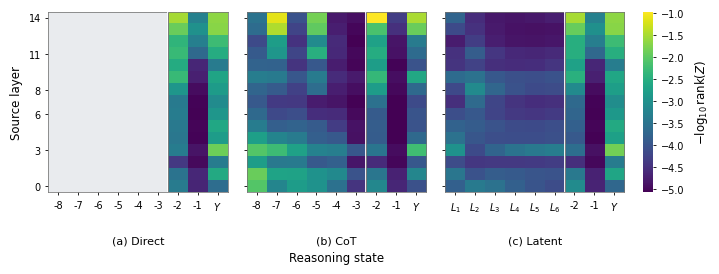

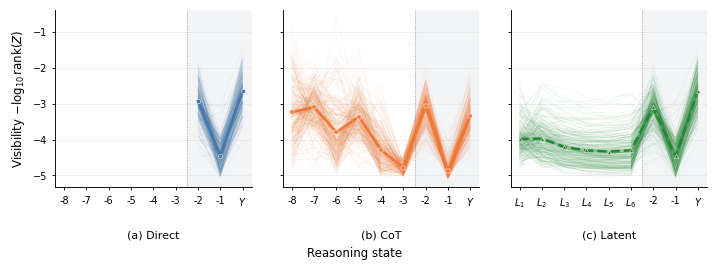

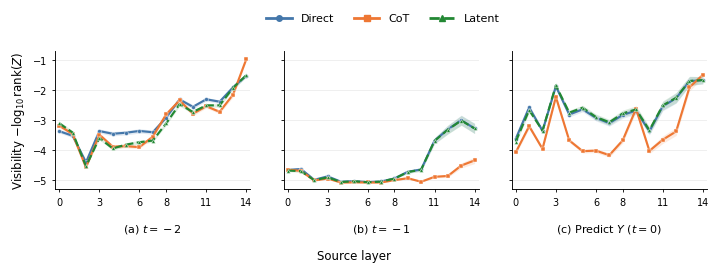

Saved paper figures as vector PDF and 450-dpi PNG.
Global layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Gray heatmap cells = unavailable states, not zero visibility.
Sample counts and pointwise 95% CIs are in the stats CSV files.


In [15]:
# Paper-ready replacement for your entire plotting Block 2.
# No model rerun. Requires CSV/metadata produced by computation Block 1.
# Saves: layer x trajectory heatmap; global trajectory lines;
#        final-state layer profiles. No overall or subplot titles.
# Final state labels default to relative positions; verify alignment before
# setting USE_VERIFIED_ANSWER_LABELS=True.
# Missing heatmap cells are gray, not zero; the default color scale is not clipped.
# CIs are pointwise problem-bootstrap intervals, not 10--90% ranges.
# Earlier slots are mode-specific, not semantically aligned across modes.
# Numerical aggregation and correct-only selection are unchanged.

import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

OUT = Path(globals().get("OUT", r"D:\Researches\InterpreteJLens\jlens_outputs"))
N_BOOT = 3000
BOOT_SEED = 2026
SHOW_PROBLEM_LINES = True      # thin traces in depth-averaged line plot
PLOT_GLOBAL_LAYERS = None      # None = saved fixed set; or e.g. [10, 11, 12, 13]
# Set True ONLY after inspecting the alignment audit in Block 1.
USE_VERIFIED_ANSWER_LABELS = False

# Only visibility by default; add "specificity" to produce the second set.
PLOT_METRICS = ("visibility",)
PANEL_LABELS = True  # small labels BELOW panels; False removes those too
HEATMAP_CMAP = "viridis"
# None uses the full finite data range, shared across all three modes.
HEATMAP_VISIBILITY_LIMITS = None
SAVE_SVG = False
PAPER_WIDTH = 7.2  # inches; suitable for a two-column-width figure

metadata = json.loads((OUT / "three_mode_metadata.json").read_text(encoding="utf-8"))
layer_z = pd.read_csv(OUT / "three_mode_layer_Z.csv", dtype={"Z": str})
layer_problem = pd.read_csv(OUT / "three_mode_layer_problem.csv")
LAYERS = sorted(layer_problem.layer.unique().astype(int).tolist())
GLOBAL = (metadata["global_layers"] if PLOT_GLOBAL_LAYERS is None
          else sorted(set(PLOT_GLOBAL_LAYERS)))
if not GLOBAL or not set(GLOBAL).issubset(LAYERS):
    raise ValueError("Select nonempty GLOBAL layers present in the saved measurements.")

# Recompute from per-Z measurements so changing GLOBAL never reruns the model.
_keys = ["dataset_idx", "z_idx", "Z", "mode", "x", "step", "phase"]
_selected = layer_z[layer_z.layer.isin(GLOBAL)]
_counts = _selected.groupby(_keys).layer.agg(["size", "nunique"])
if not ((_counts["size"] == len(GLOBAL)) & (_counts["nunique"] == len(GLOBAL))).all():
    raise ValueError("Incomplete/duplicate layer coverage: cannot compute a fixed-layer mean.")
_global_z = _selected.groupby(_keys, as_index=False)[["visibility", "specificity"]].mean()
global_problem = _global_z.groupby(["dataset_idx", "mode", "x"], as_index=False)[["visibility", "specificity"]].mean()

MODES = ("Direct", "CoT", "Latent")
COLORS = {"Direct": "#4477AA", "CoT": "#EE7733", "Latent": "#228833"}
STYLES = {"Direct": "-", "CoT": "-", "Latent": "--"}
MARKERS = {"Direct": "o", "CoT": "s", "Latent": "^"}
YLABELS = {
    "visibility": r"Visibility $-\log_{10}\mathrm{rank}(Z)$",
    "specificity": r"Specificity $P[V(Z)>V(Z^-)]$",
}
MODE_HANDLES = [Line2D([0], [0], color=COLORS[m], ls=STYLES[m],
                       marker=MARKERS[m], lw=2, markersize=4, label=m)
                for m in MODES]


def problem_bootstrap(frame, metric, columns, n_boot=N_BOOT, seed=BOOT_SEED):
    """Paired cluster bootstrap: the same resampled problems for all columns.

    Missing early positions stay missing. Means use available problems at x;
    n is reported. Intervals are pointwise, not simultaneous confidence bands.
    """
    if frame.duplicated(["dataset_idx"] + columns).any():
        raise ValueError("Input must contain one observation per problem and cell.")
    table = frame.pivot(index="dataset_idx", columns=columns, values=metric).sort_index()
    a = table.to_numpy(float)
    valid = np.isfinite(a)
    values = np.where(valid, a, 0.0)
    count = valid.sum(0)
    mean = np.divide(values.sum(0), count, out=np.full(a.shape[1], np.nan), where=count > 0)
    rng = np.random.default_rng(seed)
    boot = np.empty((n_boot, a.shape[1]))
    n = len(table)
    for start in range(0, n_boot, 128):
        k = min(128, n_boot-start)
        weights = rng.multinomial(n, np.full(n, 1/n), size=k)
        denom = weights @ valid.astype(float)
        boot[start:start+k] = np.divide(
            weights @ values, denom,
            out=np.full(denom.shape, np.nan), where=denom > 0,
        )
    lower, upper = np.nanpercentile(boot, [2.5, 97.5], axis=0)
    lower[count < 2] = np.nan
    upper[count < 2] = np.nan
    result = table.columns.to_frame(index=False)
    result["mean"], result["lower"], result["upper"], result["n"] = mean, lower, upper, count
    return result


PAPER_STYLE = {
    "font.family": "DejaVu Sans", "font.size": 8,
    "axes.labelsize": 8.5, "xtick.labelsize": 7, "ytick.labelsize": 7,
    "legend.fontsize": 8, "axes.linewidth": 0.65,
    "xtick.major.width": 0.6, "ytick.major.width": 0.6,
    "xtick.major.size": 2.5, "ytick.major.size": 2.5,
    "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
    "savefig.facecolor": "white", "axes.facecolor": "white",
    "mathtext.fontset": "dejavusans",
}


def _clean(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", color="0.90", linewidth=0.45)
    ax.set_axisbelow(True)


def _panel(ax, text):
    # Identification labels below the panels, not titles.
    if PANEL_LABELS:
        ax.text(0.5, -0.24, text, ha="center", va="top",
                transform=ax.transAxes, fontsize=8)


def _tick_labels(xs, mode=None):
    labels = []
    latent_start = -(metadata["num_latents"] + metadata["final_text_steps"] - 1)
    for x in xs:
        if x == 0:
            label = r"$Y$"
        elif USE_VERIFIED_ANSWER_LABELS and x in (-2, -1):
            label = {-2: "Answer", -1: ":"}[x]
        elif mode == "Latent" and latent_start <= x < -2:
            label = rf"$L_{{{int(x-latent_start+1)}}}$"
        else:
            label = str(int(x))
        labels.append(label)
    return labels


def _trajectory_axis(ax, xs, mode, highlight=True):
    ax.set_xticks(xs)
    ax.set_xticklabels(_tick_labels(xs, mode))
    ax.set_xlim(min(xs)-0.4, max(xs)+0.4)
    if highlight:
        ax.axvspan(-2.5, 0.4, color="#EEF0F3", alpha=0.7, zorder=0)
        ax.axvline(-2.5, color="0.55", linewidth=0.6, linestyle=":")


def _save_paper(fig, stem):
    fig.savefig(OUT / f"{stem}.pdf", bbox_inches="tight", pad_inches=0.025)
    fig.savefig(OUT / f"{stem}.png", dpi=450, bbox_inches="tight", pad_inches=0.025)
    if SAVE_SVG:
        fig.savefig(OUT / f"{stem}.svg", bbox_inches="tight", pad_inches=0.025)
    plt.show()
    plt.close(fig)


def paper_layer_heatmap(metric, stats):
    """Same axes and one full-range color scale; gray cells are unavailable."""
    xs = np.sort(stats.x.unique())
    finite = stats["mean"].to_numpy(float)
    finite = finite[np.isfinite(finite)]
    if not len(finite):
        raise ValueError(f"No finite values for {metric}.")
    if metric == "specificity":
        lo, hi = 0.0, 1.0
    elif HEATMAP_VISIBILITY_LIMITS is None:
        lo, hi = float(finite.min()), float(finite.max())
    else:
        lo, hi = map(float, HEATMAP_VISIBILITY_LIMITS)
    if lo > hi:
        raise ValueError("Heatmap minimum must not exceed maximum.")
    if lo == hi:
        lo, hi = lo-0.05, hi+0.05
    extend = ("both" if finite.min() < lo and finite.max() > hi else
              "min" if finite.min() < lo else "max" if finite.max() > hi else "neither")
    cmap = plt.get_cmap(HEATMAP_CMAP).copy()
    cmap.set_bad("#E9EBEE")
    fig = plt.figure(figsize=(PAPER_WIDTH, 2.7))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1, 0.055],
                          left=0.07, right=0.91, bottom=0.29, top=0.96, wspace=0.14)
    axes = [fig.add_subplot(gs[0, k]) for k in range(3)]
    ticks_y = np.unique(np.linspace(0, len(LAYERS)-1, min(6, len(LAYERS))).round().astype(int)).tolist()
    for k, (ax, mode) in enumerate(zip(axes, MODES)):
        values = (stats[stats["mode"] == mode]
                  .pivot(index="layer", columns="x", values="mean")
                  .reindex(index=LAYERS, columns=xs).to_numpy(float))
        im = ax.imshow(np.ma.masked_invalid(values), origin="lower", aspect="auto",
                       interpolation="none", cmap=cmap, vmin=lo, vmax=hi)
        ax.set_xticks(np.arange(len(xs)))
        ax.set_xticklabels(_tick_labels(xs, mode))
        ax.set_yticks(ticks_y)
        ax.set_yticklabels([str(LAYERS[j]) for j in ticks_y])
        ax.tick_params(axis="both", length=2)
        if k:
            ax.tick_params(labelleft=False)
        else:
            ax.set_ylabel("Source layer")
        if -2 in xs:
            # Separates the three final textual slots without tinting their data.
            boundary = int(np.flatnonzero(xs == -2)[0]) - 0.5
            ax.axvline(boundary, color="white", linewidth=1.3, zorder=3)
            ax.axvline(boundary, color="0.2", linewidth=0.45, zorder=4)
        for spine in ax.spines.values():
            spine.set_linewidth(0.55)
            spine.set_color("0.45")
        _panel(ax, f"({chr(97+k)}) {mode}")
    cbar = fig.colorbar(im, cax=fig.add_subplot(gs[0, 3]), extend=extend)
    cbar.outline.set_visible(False)
    cbar.ax.tick_params(length=2)
    cbar.set_label(r"$-\log_{10}\mathrm{rank}(Z)$" if metric == "visibility"
                  else r"$P[V(Z)>V(Z^-)]$", labelpad=6)
    fig.supxlabel("Reasoning state", x=0.47, y=0.025, fontsize=8.5)
    _save_paper(fig, f"paper_layer_{metric}_heatmap")


def paper_global_lines(metric, stats, layer_tag):
    """Depth-averaged trajectory, retaining individual-problem lines."""
    fig, axes = plt.subplots(1, 3, figsize=(PAPER_WIDTH, 2.65), sharey=True)
    fig.subplots_adjust(left=0.085, right=0.99, bottom=0.30, top=0.97, wspace=0.16)
    # Same horizontal extent exposes missing early states rather than stretching
    # a short Direct trajectory to the full width of the CoT trajectory.
    xs = np.sort(stats.x.unique())
    for k, (ax, mode) in enumerate(zip(axes, MODES)):
        q = stats[stats["mode"] == mode].set_index("x").reindex(xs)
        if SHOW_PROBLEM_LINES:
            pp = (global_problem[global_problem["mode"] == mode]
                  .pivot(index="dataset_idx", columns="x", values=metric)
                  .reindex(columns=xs))
            for row in pp.to_numpy(float):
                ax.plot(xs, row, color=COLORS[mode], linewidth=0.4,
                        alpha=0.09, rasterized=True, zorder=1)
        ax.fill_between(xs, q.lower.to_numpy(), q.upper.to_numpy(),
                        color=COLORS[mode], alpha=0.22, linewidth=0, zorder=2)
        ax.plot(xs, q["mean"], color=COLORS[mode], linestyle=STYLES[mode],
                linewidth=1.8, marker=MARKERS[mode], markersize=3.0,
                markeredgewidth=0.35, markeredgecolor="white", zorder=3)
        _trajectory_axis(ax, xs, mode)
        _clean(ax)
        _panel(ax, f"({chr(97+k)}) {mode}")
    axes[0].set_ylabel(YLABELS[metric])
    if metric == "specificity":
        axes[0].set_ylim(-0.02, 1.02)
    fig.supxlabel("Reasoning state", y=0.025, fontsize=8.5)
    _save_paper(fig, f"paper_global_{metric}_{layer_tag}")


def paper_final_layer_lines(metric, stats):
    """One line-plot panel per final state; all measured layers retained."""
    fig, axes = plt.subplots(1, 3, figsize=(PAPER_WIDTH, 2.65), sharey=True)
    fig.subplots_adjust(left=0.085, right=0.99, bottom=0.30, top=0.82, wspace=0.17)
    labels = ([r"Predict Answer", r"Predict :", r"Predict $Y$"]
              if USE_VERIFIED_ANSWER_LABELS else
              [r"$t=-2$", r"$t=-1$", r"Predict $Y$ ($t=0$)"])
    ticks = [LAYERS[j] for j in np.unique(np.linspace(0, len(LAYERS)-1, min(6, len(LAYERS))).round().astype(int))]
    for k, (ax, x, label) in enumerate(zip(axes, [-2, -1, 0], labels)):
        for mode in MODES:
            q = (stats[(stats["mode"] == mode) & (stats.x == x)]
                 .set_index("layer").reindex(LAYERS))
            ax.fill_between(LAYERS, q.lower.to_numpy(), q.upper.to_numpy(),
                            color=COLORS[mode], alpha=0.15, linewidth=0)
            ax.plot(LAYERS, q["mean"], color=COLORS[mode], linestyle=STYLES[mode],
                    linewidth=1.55, marker=MARKERS[mode], markersize=2.8,
                    markeredgecolor="white", markeredgewidth=0.3)
        ax.set_xticks(ticks)
        ax.set_xlim(min(LAYERS)-0.3, max(LAYERS)+0.3)
        _clean(ax)
        _panel(ax, f"({chr(97+k)}) {label}")
    axes[0].set_ylabel(YLABELS[metric])
    if metric == "specificity":
        axes[0].set_ylim(-0.02, 1.02)
    fig.legend(handles=MODE_HANDLES, loc="upper center", bbox_to_anchor=(0.54, 1.0),
               ncol=3, frameon=False, handlelength=2.3, columnspacing=1.8)
    fig.supxlabel("Source layer", y=0.025, fontsize=8.5)
    _save_paper(fig, f"paper_final_layer_{metric}_lines")


layer_tag = "layers_" + "_".join(map(str, GLOBAL))
with plt.rc_context(PAPER_STYLE):
    for metric in PLOT_METRICS:
        if metric not in ("visibility", "specificity"):
            raise ValueError("PLOT_METRICS supports visibility and specificity.")
        global_stats = problem_bootstrap(global_problem, metric, ["mode", "x"])
        layer_stats = problem_bootstrap(layer_problem, metric, ["mode", "layer", "x"])
        global_stats.to_csv(OUT / f"paper_global_{metric}_{layer_tag}_stats.csv", index=False)
        layer_stats.to_csv(OUT / f"paper_layer_{metric}_stats.csv", index=False)
        paper_layer_heatmap(metric, layer_stats)
        paper_global_lines(metric, global_stats, layer_tag)
        paper_final_layer_lines(metric, layer_stats)

print("Saved paper figures as vector PDF and 450-dpi PNG.")
print("Global layers:", GLOBAL)
print("Gray heatmap cells = unavailable states, not zero visibility.")
print("Sample counts and pointwise 95% CIs are in the stats CSV files.")


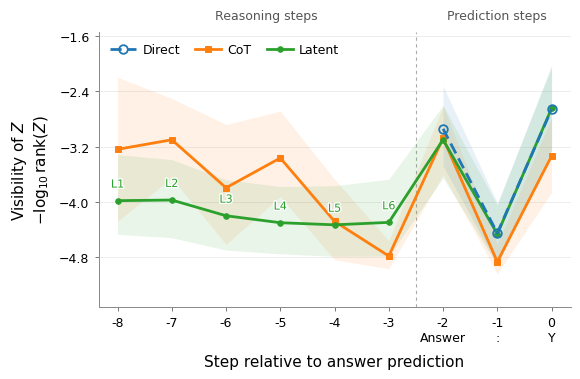

,mode,x,n,mean,low,high
0,CoT,-8,263,-3.2399,-4.2819,-2.1943
1,CoT,-7,263,-3.1009,-3.6556,-2.4996
2,CoT,-6,263,-3.7976,-4.6181,-2.8798
3,CoT,-5,263,-3.3653,-3.9245,-2.6846
4,CoT,-4,263,-4.2847,-4.8411,-3.6722
5,CoT,-3,263,-4.7879,-4.9722,-4.5685
6,CoT,-2,263,-3.0767,-3.6074,-2.6109
7,CoT,-1,263,-4.8718,-5.0464,-4.6149
8,CoT,0,263,-3.3350,-3.8633,-2.7867
9,Direct,-2,263,-2.9417,-3.4783,-2.3224


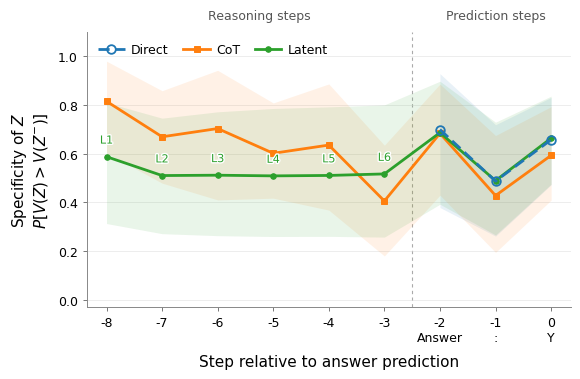

,mode,x,n,mean,low,high
0,CoT,-8,263,0.8146,0.6028,0.9792
1,CoT,-7,263,0.6690,0.4789,0.8580
2,CoT,-6,263,0.7028,0.4102,0.9415
3,CoT,-5,263,0.6013,0.4173,0.8078
4,CoT,-4,263,0.6351,0.3684,0.8857
5,CoT,-3,263,0.4058,0.1803,0.6344
6,CoT,-2,263,0.6829,0.4295,0.8851
7,CoT,-1,263,0.4278,0.1950,0.6742
8,CoT,0,263,0.5927,0.4092,0.7925
9,Direct,-2,263,0.6988,0.3789,0.9278


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

from pathlib import Path
from matplotlib.ticker import MaxNLocator


BAND = (10, 90)
MODES = ("Direct", "CoT", "Latent")

COLORS = {
    "Direct": "#1f77b4",
    "CoT": "#ff7f0e",
    "Latent": "#2ca02c",
}

PAPER_STYLE = {
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.linewidth": 0.7,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
}


# ============================================================
# 1. Problem-level summary
# ============================================================

def summarize_trajectory(df, metric):
    required = ["mode", "x", "dataset_idx", metric]
    missing = set(required) - set(df.columns)

    if missing:
        raise ValueError(f"Missing columns: {sorted(missing)}")

    data = df[required].copy()
    data[metric] = pd.to_numeric(data[metric], errors="coerce")
    data = data.replace([np.inf, -np.inf], np.nan).dropna()

    # Each problem receives equal weight at each mode / step.
    problem = (
        data.groupby(
            ["mode", "x", "dataset_idx"],
            as_index=False,
            observed=True,
        )[metric]
        .mean()
    )

    rows = []

    for (mode, x), group in problem.groupby(
        ["mode", "x"],
        observed=True,
    ):
        values = group[metric].to_numpy(float)

        rows.append({
            "mode": mode,
            "x": x,
            "n": len(values),
            "mean": values.mean(),
            "low": np.percentile(values, BAND[0]),
            "high": np.percentile(values, BAND[1]),
        })

    if not rows:
        raise ValueError(f"No valid observations for {metric!r}.")

    return (
        pd.DataFrame(rows)
        .sort_values(["mode", "x"])
        .reset_index(drop=True)
    )


# ============================================================
# 2. Three-mode trajectory plot
# ============================================================

def plot_three_mode_trajectory(
    df,
    metric="visibility",
    save_path=None,
    num_latents=None,
    final_text_steps=None,
    figsize=(5.8, 3.8),
    legend_loc="upper left",
):
    if metric not in ("visibility", "specificity"):
        raise ValueError(
            "metric must be 'visibility' or 'specificity'."
        )

    if num_latents is None:
        num_latents = NUM_LATENTS

    if final_text_steps is None:
        final_text_steps = FINAL_TEXT_STEPS

    # This figure explicitly labels three final textual states.
    if final_text_steps != 3:
        raise ValueError(
            "Answer / : / Y labels require FINAL_TEXT_STEPS == 3."
        )

    summary = summarize_trajectory(df, metric)

    latent_start = -(num_latents + final_text_steps - 1)
    final_start = -(final_text_steps - 1)
    boundary = final_start - 0.5

    min_x = int(np.floor(summary["x"].min()))
    max_x = max(0, int(np.ceil(summary["x"].max())))

    styles = {
        "Direct": dict(
            marker="o",
            markersize=6.2,
            markerfacecolor="none",
            markeredgewidth=1.3,
            linestyle=(0, (4, 2)),
            zorder=7,
        ),
        "CoT": dict(
            marker="s",
            markersize=4.0,
            markerfacecolor=COLORS["CoT"],
            markeredgewidth=0.7,
            linestyle="-",
            zorder=5,
        ),
        "Latent": dict(
            marker="o",
            markersize=4.0,
            markerfacecolor=COLORS["Latent"],
            markeredgewidth=0.7,
            linestyle="-",
            zorder=6,
        ),
    }

    with plt.rc_context(PAPER_STYLE):
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_axisbelow(True)

        # ----------------------------------------------------
        # Percentile bands across problems
        # ----------------------------------------------------

        for mode in MODES:
            d = summary.loc[
                summary["mode"].eq(mode)
            ].sort_values("x")

            if d.empty:
                continue

            ax.fill_between(
                d["x"].to_numpy(float),
                d["low"].to_numpy(float),
                d["high"].to_numpy(float),
                color=COLORS[mode],
                alpha=0.10,
                linewidth=0,
                zorder=1,
            )

        # ----------------------------------------------------
        # Mean trajectories
        # ----------------------------------------------------

        handles = {}

        # Direct is drawn last to keep overlapping points visible.
        for mode in ("CoT", "Latent", "Direct"):
            d = summary.loc[
                summary["mode"].eq(mode)
            ].sort_values("x")

            if d.empty:
                continue

            handles[mode], = ax.plot(
                d["x"],
                d["mean"],
                color=COLORS[mode],
                markeredgecolor=COLORS[mode],
                linewidth=2.0,
                label=mode,
                **styles[mode],
            )

        # ----------------------------------------------------
        # L1 ... L6 above latent mean points
        # ----------------------------------------------------

        latent = summary.loc[
            summary["mode"].eq("Latent")
        ]

        for i in range(num_latents):
            x_pos = latent_start + i
            point = latent.loc[latent["x"].eq(x_pos)]

            if point.empty:
                continue

            label = ax.annotate(
                f"L{i + 1}",
                xy=(x_pos, point.iloc[0]["mean"]),
                xytext=(0, 8),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
                color=COLORS["Latent"],
                zorder=10,
            )

            label.set_path_effects([
                pe.withStroke(
                    linewidth=2,
                    foreground="white",
                )
            ])

        # ----------------------------------------------------
        # X-axis: relative steps and final textual states
        # ----------------------------------------------------

        ticks = np.arange(min_x, max_x + 1)

        token_labels = {
            -2: "Answer",
            -1: ":",
             0: "Y",
        }

        ax.set_xticks(ticks)
        ax.set_xticklabels([
            f"{x}\n{token_labels[x]}"
            if x in token_labels else str(x)
            for x in ticks
        ])

        ax.set_xlim(min_x - 0.35, max_x + 0.35)

        ax.set_xlabel(
            "Step relative to answer prediction",
            labelpad=7,
        )

        # ----------------------------------------------------
        # Reasoning / prediction stages
        # ----------------------------------------------------

        transform = ax.get_xaxis_transform()

        if min_x < final_start:
            ax.axvline(
                boundary,
                color="#aaaaaa",
                linewidth=0.8,
                linestyle=(0, (3, 3)),
                zorder=0,
            )

            ax.text(
                (min_x + boundary) / 2,
                1.035,
                "Reasoning steps",
                transform=transform,
                ha="center",
                va="bottom",
                fontsize=9,
                color="#555555",
                clip_on=False,
            )

        ax.text(
            -1,
            1.035,
            "Prediction steps",
            transform=transform,
            ha="center",
            va="bottom",
            fontsize=9,
            color="#555555",
            clip_on=False,
        )

        # ----------------------------------------------------
        # Y-axis
        # ----------------------------------------------------

        if metric == "visibility":
            ax.set_ylabel(
                r"Visibility of $Z$"
                "\n"
                r"$-\log_{10}\mathrm{rank}(Z)$",
                labelpad=6,
            )

            ax.margins(y=0.16)
            ax.yaxis.set_major_locator(
                MaxNLocator(nbins=5)
            )

        else:
            ax.set_ylabel(
                r"Specificity of $Z$"
                "\n"
                r"$P[V(Z)>V(Z^{-})]$",
                labelpad=6,
            )

            ax.set_ylim(-0.03, 1.10)
            ax.set_yticks(np.linspace(0, 1, 6))

        # ----------------------------------------------------
        # Style
        # ----------------------------------------------------

        ax.grid(
            axis="y",
            color="#d9d9d9",
            linewidth=0.6,
            alpha=0.55,
        )

        ax.tick_params(
            axis="both",
            direction="out",
            length=3,
            width=0.7,
            color="#777777",
        )

        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        for side in ("left", "bottom"):
            ax.spines[side].set_color("#888888")

        ax.legend(
            handles=[
                handles[m] for m in MODES if m in handles
            ],
            labels=[
                m for m in MODES if m in handles
            ],
            loc=legend_loc,
            ncol=3,
            frameon=False,
            handlelength=2.1,
            handletextpad=0.5,
            columnspacing=1.2,
            borderaxespad=0.5,
        )

        fig.tight_layout(pad=0.7)

        # ----------------------------------------------------
        # Export
        # ----------------------------------------------------

        if save_path is not None:
            path = Path(save_path)
            path.parent.mkdir(parents=True, exist_ok=True)

            for extension in (".pdf", ".png"):
                fig.savefig(
                    path.with_suffix(extension),
                    dpi=400,
                    bbox_inches="tight",
                    pad_inches=0.04,
                )

        plt.show()

    return summary


# ============================================================
# 3. Visibility
# ============================================================

visibility3_summary = plot_three_mode_trajectory(
    trajectory3_problem_df,
    metric="visibility",
    save_path=Path(OUT) / "three_mode_visibility_full_trajectory.pdf",
)

display(visibility3_summary.round(4))


# ============================================================
# 4. Specificity
# ============================================================

specificity3_summary = plot_three_mode_trajectory(
    trajectory3_problem_df,
    metric="specificity",
    save_path=Path(OUT) / "three_mode_specificity_full_trajectory.pdf",
)

display(specificity3_summary.round(4))

## What happens in CoT

In [ ]:
MAX_SCAN = None

Canonical problems=263 | Canonical Z=420
Scan 263/263 | emission=4618 | full=11107
Problems=263 | Z=420 | full rows=11107
Exclusions: {}
Problems=263 | Z=420 | rows=4618
Exclusions: {}


,tau,n,V_jlens,V_jlens_lo,V_jlens_hi,V_lm,V_lm_lo,V_lm_hi,Spec_jlens,Spec_jlens_lo,Spec_jlens_hi
0,-5,263,-4.0462,-4.0995,-3.9911,-2.2716,-2.3370,-2.2083,0.5900,0.5671,0.6131
1,-4,263,-2.2292,-2.2991,-2.1620,-0.9155,-0.9774,-0.8560,0.7118,0.6911,0.7325
2,-3,263,-3.8150,-3.8825,-3.7433,-2.7717,-2.8555,-2.6889,0.6810,0.6564,0.7057
3,-2,263,-2.9367,-2.9938,-2.8776,-1.1197,-1.1796,-1.0584,0.6870,0.6689,0.7048
4,-1,263,-3.9361,-4.0014,-3.8695,-2.9760,-3.0616,-2.8905,0.6864,0.6649,0.7078
5,0,263,-2.5381,-2.5962,-2.4813,0.0000,0.0000,0.0000,0.6860,0.6672,0.7043
6,1,263,-2.5590,-2.6448,-2.4753,-3.8455,-3.9325,-3.7590,0.9326,0.9255,0.9392
7,2,263,-4.4145,-4.4419,-4.3866,-1.8213,-1.8812,-1.7613,0.5186,0.4983,0.5392
8,3,263,-2.3871,-2.4343,-2.3396,-0.1908,-0.2161,-0.1664,0.6952,0.6785,0.7120
9,4,263,-3.1778,-3.2757,-3.0774,-2.4277,-2.5185,-2.3395,0.8209,0.8018,0.8403


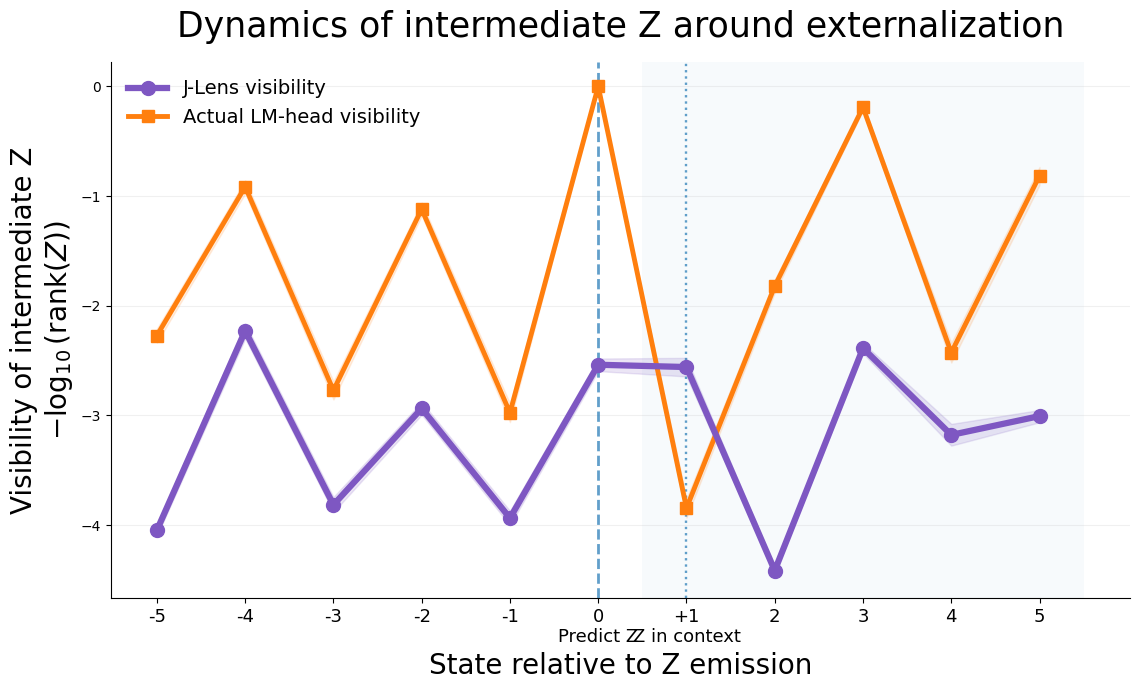

Saved: D:\Researches\InterpreteJLens\jlens_outputs\emission_dynamics_corrected.png

Mechanistic phase summary


,Phase,n,V_jlens,V_jlens_95CI,V_lm,V_lm_95CI,Spec_jlens,Spec_jlens_95CI
0,Pre-emission,263,-3.393,"[-3.434, -3.351]",-2.011,"[-2.059, -1.962]",0.671,"[0.655, 0.687]"
1,Emission,263,-2.538,"[-2.596, -2.481]",0.000,"[0.000, 0.000]",0.686,"[0.667, 0.704]"
2,Z in context,263,-2.559,"[-2.645, -2.475]",-3.845,"[-3.932, -3.759]",0.933,"[0.926, 0.939]"
3,Later post,263,-3.246,"[-3.282, -3.211]",-1.314,"[-1.354, -1.274]",0.680,"[0.669, 0.691]"



Example event-level rows:


,dataset_idx,Z,tau,phase,state_token,next_token,V_jlens,V_lm,Spec_jlens
4,0,7,-1,Pre-emission,4,=,-4.554428,-3.153510,0.186667
5,0,7,0,Predict Z,=,7,-2.997731,-0.000000,0.586667
6,0,7,1,Z in context,7,>>\n,-3.105327,-4.964722,0.933333
7,0,7,2,Later post,>>\n,<<,-4.489029,-1.591065,0.546667
15,0,9,-1,Pre-emission,7,=,-4.562478,-3.778079,0.213333
16,0,9,0,Predict Z,=,9,-3.533651,-0.000000,0.346667
17,0,9,1,Z in context,9,>>\n,-2.763850,-4.319856,1.000000
18,0,9,2,Later post,>>\n,<<,-4.472098,-2.287802,0.480000
26,1,1,-1,Pre-emission,2,=,-3.004112,-1.301030,0.885714
27,1,1,0,Predict Z,=,1,-1.927245,-0.000000,0.933333



Corrected event-centered contrasts (second minus first):


,metric,contrast,n,delta,CI_low,CI_high
0,J-Lens visibility,Pre-emission -> Predict Z,263,1.3981,1.3175,1.4783
1,J-Lens visibility,Predict Z -> Z in context,263,-0.0210,-0.1111,0.0687
2,Actual LM visibility,Pre-emission -> Predict Z,263,2.9760,2.8905,3.0616
3,Actual LM visibility,Predict Z -> Z in context,263,-3.8455,-3.9325,-3.7590
4,J-Lens specificity,Pre-emission -> Predict Z,263,-0.0004,-0.0247,0.0234
5,J-Lens specificity,Predict Z -> Z in context,263,0.2466,0.2288,0.2651



Saved corrected emission analysis.


In [17]:
# ============================================================
# CORRECTED EMISSION-CENTERED ANALYSIS
#
# trace[t] = state AFTER token t is in context
#          = state predicting generated token t+1
#
# tau < 0 : pre-emission
# tau = 0 : predicts / emits Z
# tau = 1 : Z has just entered context
# tau > 1 : later post-externalization
# ============================================================

from collections import Counter
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

EMISSION_RADIUS = 5
MAX_SCAN = None
RELATIVE_STEPS = list(range(-EMISSION_RADIUS, EMISSION_RADIUS + 1))


# ============================================================
# 1. Basic readouts
# ============================================================

def target_visibility_from_logits(logits, target_id):
    target = logits[:, target_id]
    ranks = (logits > target[:, None]).sum(dim=-1) + 1
    return -torch.log10(ranks.float()).detach().cpu().numpy()


def jlens_visibility_matrix(trace, Z, steps):
    target_id = one_token_id(Z)
    if target_id is None or not steps or any(s < 0 or s >= trace.shape[0] for s in steps):
        return None

    device = next(coconut_hf_model.parameters()).device
    trace_tensor = torch.as_tensor(trace)
    cols = []

    with torch.no_grad():
        for layer in ANALYSIS_LAYERS:
            residuals = trace_tensor[steps, layer].to(device=device, dtype=torch.float32)
            transported = coconut_lens.transport(residuals, layer=layer)
            logits = coconut_lens_model.unembed(transported).float()
            cols.append(target_visibility_from_logits(logits, target_id))

    return np.stack(cols, axis=1)


def actual_lm_visibility(trace, Z, steps):
    target_id = one_token_id(Z)
    if target_id is None or not steps or any(s < 0 or s >= trace.shape[0] for s in steps):
        return None

    device = next(coconut_hf_model.parameters()).device
    trace_tensor = torch.as_tensor(trace)

    with torch.no_grad():
        h = trace_tensor[steps, -1].to(device=device, dtype=torch.float32)
        logits = coconut_hf_model.lm_head(coconut_hf_model.model.norm(h)).float()

    return target_visibility_from_logits(logits, target_id)


def specificity_trajectory_selected(trace, Z, wrong_values, steps):
    true_id = one_token_id(Z)
    wrong_ids = [one_token_id(v) for v in wrong_values]

    if true_id is None or not wrong_ids or any(x is None for x in wrong_ids):
        return None

    device = next(coconut_hf_model.parameters()).device
    trace_tensor = torch.as_tensor(trace)
    scores = []

    with torch.no_grad():
        for layer in ANALYSIS_LAYERS:
            residuals = trace_tensor[steps, layer].to(device=device, dtype=torch.float32)
            transported = coconut_lens.transport(residuals, layer=layer)
            logits = coconut_lens_model.unembed(transported).float()

            true_logits = logits[:, true_id]
            wrong_logits = logits[:, wrong_ids]
            scores.append((true_logits[:, None] > wrong_logits).float().mean(dim=1).cpu().numpy())

    return np.stack(scores).mean(axis=0)


def trace_aligned_token_ids(result):
    ids = result["output_ids"]
    if not torch.is_tensor(ids):
        ids = torch.tensor(ids)
    if ids.ndim == 2:
        ids = ids[0]

    n_trace = int(result["trace"].shape[0])
    if len(ids) < n_trace:
        return None

    return ids[-n_trace:].detach().cpu()

def classify_token(token, Z=None):
    raw, t = str(token), str(token).strip()
    if Z is not None and normalize_number(t) == str(Z): return "Z"
    if normalize_number(t) is not None: return "Number"
    if t == "=": return "Equals"
    if t in {"+", "-", "*", "/", "×", "÷", "%"}: return "Arithmetic operator"
    if t in {"<<", ">>", "<|eocot|>", "<|bocot|>"} or t.startswith(("<<", ">>")): return "CoT delimiter"
    if t in {".", ",", ":", ";", "(", ")", "[", "]"} or raw in {"\n", "\n\n"}: return "Punctuation"
    return "Text / other"


def build_forbidden_full(question, cot_text, intermediates, gold):
    forbidden = {gold}
    for text in (question, cot_text):
        for m in NUMBER_RE.finditer(text):
            v = normalize_number(m.group(0))
            if v is not None: forbidden.add(v)
    forbidden.update(str(x["Z"]) for x in intermediates)
    return forbidden

# ============================================================
# 2. Canonical population from THREE-MODE trajectory
# ============================================================

canonical_Z_df = (
    trajectory3_Z_df[["dataset_idx", "z_idx", "Z"]]
    .drop_duplicates()
    .copy()
)

canonical_target_counts = {
    int(idx): Counter(g["Z"].astype(str).tolist())
    for idx, g in canonical_Z_df.groupby("dataset_idx")
}

dataset_indices = sorted(canonical_target_counts)

if MAX_SCAN is not None:
    dataset_indices = dataset_indices[:MAX_SCAN]

print(
    f"Canonical problems={len(dataset_indices)} | "
    f"Canonical Z={len(canonical_Z_df)}"
)


# ============================================================
# 3. UNIFIED SCAN
# One generation + one full-trace readout per problem/Z.
# Produces BOTH emission-centered and full-CoT tables.
# ============================================================

emission_rows, emission_layer_rows, full_cot_rows = [], [], []
emission_exclusions = Counter()

for scan_i, dataset_idx in enumerate(dataset_indices):
    sample = data[dataset_idx]
    question, gold = sample["question"], gold_answer_of(sample)

    cot = run_and_trace(
        model_wrapper, question, mode="verbalized",
        max_new_tokens=MAX_NEW_TOKENS, num_latents=NUM_LATENTS
    )

    if not output_correct(cot, gold):
        emission_exclusions["cot_wrong_on_rerun"] += 1
        continue

    intermediates = extract_intermediates(cot)
    if not intermediates:
        emission_exclusions["no_intermediate"] += 1
        continue

    cot_text, _, _ = generated_alignment(cot)
    aligned_ids = trace_aligned_token_ids(cot)

    if aligned_ids is None:
        emission_exclusions["alignment_failure"] += 1
        continue

    tokens = [tokenizer.decode([int(x)]) for x in aligned_ids.tolist()]
    forbidden = build_forbidden_full(question, cot_text, intermediates, gold)
    remaining = Counter(canonical_target_counts[dataset_idx])

    # Compute metrics for ALL trace states once.
    all_steps = list(range(cot["trace"].shape[0]))

    for z_idx, info in enumerate(intermediates):
        Z = str(info["Z"])

        # Keep exactly the canonical Z population.
        if remaining[Z] <= 0:
            continue
        remaining[Z] -= 1

        z_token_step = int(info["z_token_step"])
        emission_step = int(info["emission_step"])
        written_step = int(info["written_step"])

        if z_token_step != emission_step + 1:
            raise RuntimeError(
                f"Unexpected alignment: Z={Z}, "
                f"z_token_step={z_token_step}, emission_step={emission_step}"
            )
        if written_step != z_token_step:
            raise RuntimeError("For one-token Z, written_step should equal z_token_step.")

        wrong = matched_wrong_values_all(Z, forbidden=forbidden)
        if not wrong:
            emission_exclusions["no_matched_controls"] += 1
            continue

        # -------- ONE computation over the entire trace --------
        V_layer = jlens_visibility_matrix(cot["trace"], Z, all_steps)
        V_lm = actual_lm_visibility(cot["trace"], Z, all_steps)
        Spec = specificity_trajectory_selected(cot["trace"], Z, wrong, all_steps)

        if V_layer is None or V_lm is None or Spec is None:
            emission_exclusions["metric_failure"] += 1
            continue

        V_j = V_layer.mean(axis=1)

        # ======================================================
        # A. FULL CoT TOKEN-LEVEL TRAJECTORY
        # Last state omitted because it has no generated next token.
        # ======================================================

        for step in range(min(len(tokens) - 1, len(all_steps))):
            state_token, next_token = tokens[step], tokens[step + 1]

            next_role = (
                "Predict Z"
                if normalize_number(next_token.strip()) == Z
                else classify_token(next_token)
            )

            full_cot_rows.append({
                "dataset_idx": int(dataset_idx), "z_idx": int(z_idx), "Z": Z,
                "step": int(step),
                "distance_from_Z_emission": int(step - emission_step),
                "state_token": state_token, "next_token": next_token,
                "state_role": classify_token(state_token, Z),
                "next_role": next_role,
                "V_jlens": float(V_j[step]),
                "V_lm": float(V_lm[step]),
                "Spec_jlens": float(Spec[step]),
            })

        # ======================================================
        # B. EMISSION-CENTERED WINDOW
        # Reuse values already computed above.
        # ======================================================

        for tau in RELATIVE_STEPS:
            step = emission_step + tau
            if step < 0 or step >= len(all_steps):
                continue

            state_token = tokens[step] if step < len(tokens) else ""
            next_token = tokens[step + 1] if step + 1 < len(tokens) else ""

            if tau < 0: phase = "Pre-emission"
            elif tau == 0: phase = "Predict Z"
            elif tau == 1: phase = "Z in context"
            else: phase = "Later post"

            emission_rows.append({
                "dataset_idx": int(dataset_idx), "z_idx": int(z_idx), "Z": Z,
                "tau": int(tau), "step": int(step), "phase": phase,
                "state_token": state_token, "next_token": next_token,
                "z_token_step": z_token_step, "emission_step": emission_step,
                "written_step": written_step,
                "V_jlens": float(V_j[step]), "V_lm": float(V_lm[step]),
                "readout_gap": float(V_lm[step] - V_j[step]),
                "Spec_jlens": float(Spec[step]), "n_wrong": len(wrong),
            })

            for j, layer in enumerate(ANALYSIS_LAYERS):
                emission_layer_rows.append({
                    "dataset_idx": int(dataset_idx), "z_idx": int(z_idx), "Z": Z,
                    "tau": int(tau), "phase": phase, "layer": int(layer),
                    "V_jlens": float(V_layer[step, j]),
                })

    print(
        f"\rScan {scan_i+1}/{len(dataset_indices)} | "
        f"emission={len(emission_rows)} | full={len(full_cot_rows)}",
        end=""
    )

print()

emission_obs_df = pd.DataFrame(emission_rows)
emission_layer_obs_df = pd.DataFrame(emission_layer_rows)
full_cot_df = pd.DataFrame(full_cot_rows)

if emission_obs_df.empty or full_cot_df.empty:
    raise RuntimeError("No valid observations.")

print(
    f"Problems={full_cot_df['dataset_idx'].nunique()} | "
    f"Z={full_cot_df[['dataset_idx','z_idx']].drop_duplicates().shape[0]} | "
    f"full rows={len(full_cot_df)}"
)
print("Exclusions:", dict(emission_exclusions))

full_cot_df.to_csv(OUT / "full_cot_token_audit.csv", index=False)


# ============================================================
# 4. DataFrames + one problem = one vote
# ============================================================

emission_obs_df = pd.DataFrame(emission_rows)
emission_layer_obs_df = pd.DataFrame(emission_layer_rows)

if emission_obs_df.empty:
    raise RuntimeError("No valid corrected emission observations.")

emission_problem_df = (
    emission_obs_df
    .groupby(["dataset_idx", "tau"], as_index=False)
    [["V_jlens", "V_lm", "readout_gap", "Spec_jlens"]]
    .mean()
)

print(
    f"Problems={emission_obs_df['dataset_idx'].nunique()} | "
    f"Z={emission_obs_df[['dataset_idx','z_idx']].drop_duplicates().shape[0]} | "
    f"rows={len(emission_obs_df)}"
)
print("Exclusions:", dict(emission_exclusions))


# ============================================================
# 5. Bootstrap helpers
# ============================================================

def bootstrap_mean_ci(values, n_boot=10000, seed=42):
    v = np.asarray(values, float)
    v = v[np.isfinite(v)]
    if len(v) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot = v[rng.integers(0, len(v), size=(n_boot, len(v)))].mean(axis=1)
    return float(v.mean()), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))


# Self-contained paired bootstrap:
# returns metric(tau_b) - metric(tau_a)
def paired_diff_ci(a, b, n_boot=10000, seed=42):
    a, b = np.asarray(a, float), np.asarray(b, float)
    mask = np.isfinite(a) & np.isfinite(b)
    d = b[mask] - a[mask]

    if len(d) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    boot = d[rng.integers(0, len(d), size=(n_boot, len(d)))].mean(axis=1)
    return float(d.mean()), float(np.percentile(boot, 2.5)), float(np.percentile(boot, 97.5))


# ============================================================
# 6. Tau-level trajectory
# ============================================================

trajectory_rows = []

for tau in RELATIVE_STEPS:
    sub = emission_problem_df[emission_problem_df["tau"] == tau]
    if sub.empty:
        continue

    row = {"tau": tau, "n": sub["dataset_idx"].nunique()}

    for metric in ["V_jlens", "V_lm", "Spec_jlens"]:
        mean, lo, hi = bootstrap_mean_ci(sub[metric])
        row[metric] = mean
        row[f"{metric}_lo"] = lo
        row[f"{metric}_hi"] = hi

    trajectory_rows.append(row)

trajectory_df = pd.DataFrame(trajectory_rows)
display(trajectory_df.round(4))


# ============================================================
# 7. Main visibility figure
# ============================================================

fig, ax = plt.subplots(figsize=(11.5, 7.0))
palette = plt.rcParamsDefault["axes.prop_cycle"].by_key()["color"]

ax.plot(
    trajectory_df["tau"], trajectory_df["V_jlens"],
    marker="o", linewidth=4.5, markersize=10,
    color="#7E57C2", label="J-Lens visibility", zorder=10
)
ax.fill_between(
    trajectory_df["tau"], trajectory_df["V_jlens_lo"], trajectory_df["V_jlens_hi"],
    color="#7E57C2", alpha=0.15
)

ax.plot(
    trajectory_df["tau"], trajectory_df["V_lm"],
    marker="s", linewidth=3.5, markersize=8,
    color=palette[1], label="Actual LM-head visibility", zorder=9
)
ax.fill_between(
    trajectory_df["tau"], trajectory_df["V_lm_lo"], trajectory_df["V_lm_hi"],
    color=palette[1], alpha=0.12
)

ax.axvline(0, linewidth=2.0, linestyle="--", alpha=0.7)
ax.axvline(1, linewidth=1.7, linestyle=":", alpha=0.7)
ax.axvspan(0.5, EMISSION_RADIUS + 0.5, alpha=0.035)

ax.set_xticks(RELATIVE_STEPS)
tick_labels = [str(t) for t in RELATIVE_STEPS]
tick_labels[RELATIVE_STEPS.index(0)] = "0\nPredict Z"
tick_labels[RELATIVE_STEPS.index(1)] = "+1\nZ in context"
ax.set_xticklabels(tick_labels, fontsize=13)

ax.set_xlabel("State relative to Z emission", fontsize=20)
ax.set_ylabel("Visibility of intermediate Z\n" + r"$-\log_{10}(\mathrm{rank}(Z))$", fontsize=20)
ax.set_title("Dynamics of intermediate Z around externalization", fontsize=25, pad=18)
ax.grid(axis="y", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=14)

fig.tight_layout()
path = OUT / "emission_dynamics_corrected.png"
fig.savefig(path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", path)


# ============================================================
# 8. Phase-level summary
# ============================================================

def phase_from_tau(tau):
    if tau <= -1:
        return "Pre-emission"
    if tau == 0:
        return "Emission"
    if tau == 1:
        return "Z in context"
    return "Later post"


phase_problem_df = emission_problem_df.copy()
phase_problem_df["phase"] = phase_problem_df["tau"].map(phase_from_tau)

phase_problem_df = (
    phase_problem_df
    .groupby(["dataset_idx", "phase"], as_index=False)
    [["V_jlens", "V_lm", "Spec_jlens"]]
    .mean()
)

phase_rows = []
for phase in ["Pre-emission", "Emission", "Z in context", "Later post"]:
    sub = phase_problem_df[phase_problem_df["phase"] == phase]
    if sub.empty:
        continue

    row = {"Phase": phase, "n": sub["dataset_idx"].nunique()}
    for metric in ["V_jlens", "V_lm", "Spec_jlens"]:
        mean, lo, hi = bootstrap_mean_ci(sub[metric])
        row[metric] = mean
        row[f"{metric}_95CI"] = f"[{lo:.3f}, {hi:.3f}]"
    phase_rows.append(row)

phase_summary_df = pd.DataFrame(phase_rows)

print("\nMechanistic phase summary")
display(phase_summary_df.round({"V_jlens": 3, "V_lm": 3, "Spec_jlens": 3}))


# ============================================================
# 9. Example event-level table
# ============================================================

event_table_df = (
    emission_obs_df[emission_obs_df["tau"].isin([-1, 0, 1, 2])]
    [["dataset_idx", "Z", "tau", "phase", "state_token", "next_token",
      "V_jlens", "V_lm", "Spec_jlens"]]
    .sort_values(["dataset_idx", "Z", "tau"])
)

print("\nExample event-level rows:")
display(event_table_df.head(24))


# ============================================================
# 10. Paired event contrasts
# ============================================================

def paired_tau_contrast(df, metric, tau_a, tau_b):
    sub = (
        df[df["tau"].isin([tau_a, tau_b])]
        .pivot(index="dataset_idx", columns="tau", values=metric)
        .dropna()
    )

    if tau_a not in sub.columns or tau_b not in sub.columns:
        return np.nan, np.nan, np.nan, 0

    d, lo, hi = paired_diff_ci(sub[tau_a], sub[tau_b])
    return d, lo, hi, len(sub)


contrast_rows = []

for metric, label in [
    ("V_jlens", "J-Lens visibility"),
    ("V_lm", "Actual LM visibility"),
    ("Spec_jlens", "J-Lens specificity"),
]:
    for a, b, name in [
        (-1, 0, "Pre-emission -> Predict Z"),
        (0, 1, "Predict Z -> Z in context"),
    ]:
        d, lo, hi, n = paired_tau_contrast(emission_problem_df, metric, a, b)
        contrast_rows.append({
            "metric": label, "contrast": name, "n": n,
            "delta": d, "CI_low": lo, "CI_high": hi
        })

contrast_df = pd.DataFrame(contrast_rows)

print("\nCorrected event-centered contrasts (second minus first):")
display(contrast_df.round(4))


# ============================================================
# 11. Save
# ============================================================

emission_obs_df.to_csv(OUT / "emission_corrected_Z_level.csv", index=False)
emission_problem_df.to_csv(OUT / "emission_corrected_problem_level.csv", index=False)
emission_layer_obs_df.to_csv(OUT / "emission_corrected_layer_Z_level.csv", index=False)
trajectory_df.to_csv(OUT / "emission_corrected_trajectory.csv", index=False)
phase_summary_df.to_csv(OUT / "emission_phase_summary.csv", index=False)
event_table_df.to_csv(OUT / "emission_event_table.csv", index=False)
contrast_df.to_csv(OUT / "emission_event_contrasts.csv", index=False)

print("\nSaved corrected emission analysis.")

In [18]:
# ============================================================
# SHOW ONE COMPLETE TRACE EXAMPLE
# ============================================================

example_key = (
    full_cot_df[["dataset_idx", "z_idx"]]
    .drop_duplicates()
    .iloc[0]
)

example_df = full_cot_df[
    (full_cot_df["dataset_idx"] == example_key["dataset_idx"]) &
    (full_cot_df["z_idx"] == example_key["z_idx"])
].copy()

print(
    f"\nFull trace example | "
    f"dataset_idx={example_key['dataset_idx']} | "
    f"Z={example_df['Z'].iloc[0]}"
)

display(
    example_df[
        [
            "step",
            "distance_from_Z_emission",
            "state_token",
            "next_token",
            "state_role",
            "next_role",
            "V_jlens",
            "V_lm",
            "Spec_jlens",
        ]
    ].round(4)
)


Full trace example | dataset_idx=0 | Z=7


,step,distance_from_Z_emission,state_token,next_token,state_role,next_role,V_jlens,V_lm,Spec_jlens
0,0,-5,<|bocot|>,<<,CoT delimiter,CoT delimiter,-4.2057,-2.1271,0.3600
1,1,-4,<<,3,CoT delimiter,Number,-2.4498,-1.2041,0.3600
2,2,-3,3,+,Number,Arithmetic operator,-4.3099,-2.4232,0.0667
3,3,-2,+,4,Arithmetic operator,Number,-3.1205,-0.6990,0.2267
4,4,-1,4,=,Number,Equals,-4.5544,-3.1535,0.1867
5,5,0,=,7,Equals,Predict Z,-2.9977,-0.0000,0.5867
6,6,1,7,>>\n,Z,CoT delimiter,-3.1053,-4.9647,0.9333
7,7,2,>>\n,<<,CoT delimiter,CoT delimiter,-4.4890,-1.5911,0.5467
8,8,3,<<,16,CoT delimiter,Number,-2.6750,-1.1461,0.3467
9,9,4,16,-,Number,Arithmetic operator,-4.2724,-1.6232,0.8533


In [19]:
# ============================================================
# TOKEN / SYMBOL EFFECT ANALYSIS
# ============================================================

ROLE_ORDER = [
    "Predict Z",
    "Number",
    "Equals",
    "Arithmetic operator",
    "CoT delimiter",
    "Punctuation",
    "Text / other",
]


# ------------------------------------------------------------
# 1. Raw role summary
# ------------------------------------------------------------

role_summary = (
    full_cot_df
    .groupby("next_role")
    .agg(
        n=("V_jlens", "size"),
        problems=("dataset_idx", "nunique"),
        V_jlens=("V_jlens", "mean"),
        V_lm=("V_lm", "mean"),
        Spec_jlens=("Spec_jlens", "mean"),
    )
    .reindex(ROLE_ORDER)
    .dropna(how="all")
    .reset_index()
)

print("Raw next-token-role summary:")
display(role_summary.round(4))


# ------------------------------------------------------------
# 2. Within-Z centered metrics
#
# Removes problem/Z-specific baseline visibility.
# ------------------------------------------------------------

centered = full_cot_df.copy()

for metric in ["V_jlens", "V_lm", "Spec_jlens"]:
    centered[f"{metric}_centered"] = (
        centered[metric]
        - centered.groupby(
            ["dataset_idx", "z_idx"]
        )[metric].transform("mean")
    )


centered_summary = (
    centered
    .groupby("next_role")
    .agg(
        n=("V_jlens_centered", "size"),
        V_jlens=("V_jlens_centered", "mean"),
        V_lm=("V_lm_centered", "mean"),
        Spec_jlens=("Spec_jlens_centered", "mean"),
    )
    .reindex(ROLE_ORDER)
    .dropna(how="all")
    .reset_index()
)

print("\nWithin-Z centered token-role effect:")
display(centered_summary.round(4))


# ------------------------------------------------------------
# 3. Bootstrap role means at problem level
# ------------------------------------------------------------

problem_role_df = (
    centered
    .groupby(["dataset_idx", "next_role"], as_index=False)
    [["V_jlens_centered", "V_lm_centered", "Spec_jlens_centered"]]
    .mean()
)


def boot_role(metric, n_boot=3000, seed=42):
    rows = []
    rng = np.random.default_rng(seed)

    for role, g in problem_role_df.groupby("next_role"):
        v = g[metric].dropna().to_numpy(float)

        boot = np.array([
            rng.choice(v, len(v), replace=True).mean()
            for _ in range(n_boot)
        ])

        rows.append({
            "role": role,
            "n": len(v),
            "mean": v.mean(),
            "CI_low": np.percentile(boot, 2.5),
            "CI_high": np.percentile(boot, 97.5),
        })

    return pd.DataFrame(rows)


V_role_boot = boot_role("V_jlens_centered")
Spec_role_boot = boot_role("Spec_jlens_centered")

print("\nJ-Lens token-role effects:")
display(V_role_boot.round(4))

print("\nSpecificity token-role effects:")
display(Spec_role_boot.round(4))

Raw next-token-role summary:


,next_role,n,problems,V_jlens,V_lm,Spec_jlens
0,Predict Z,976,263,-2.5464,0.0000,0.7010
1,Number,3535,263,-2.9550,-1.1943,0.6474
2,Equals,1284,263,-3.8907,-2.9452,0.6889
3,Arithmetic operator,1418,263,-3.6436,-2.7136,0.7265
4,CoT delimiter,2990,263,-4.0674,-3.0003,0.5992
5,Punctuation,51,18,-4.2147,-2.9760,0.5758
6,Text / other,853,263,-3.9686,-2.2864,0.5519



Within-Z centered token-role effect:


,next_role,n,V_jlens,V_lm,Spec_jlens
0,Predict Z,976,0.9293,2.0181,0.0485
1,Number,3535,0.5501,0.8856,0.0025
2,Equals,1284,-0.3900,-0.8809,0.0434
3,Arithmetic operator,1418,-0.1407,-0.6437,0.0816
4,CoT delimiter,2990,-0.5693,-0.9389,-0.0469
5,Punctuation,51,-0.6798,-0.8397,-0.0654
6,Text / other,853,-0.4859,-0.2420,-0.0982



J-Lens token-role effects:


,role,n,mean,CI_low,CI_high
0,Arithmetic operator,263,-0.0620,-0.1138,-0.0095
1,CoT delimiter,263,-0.5758,-0.5976,-0.5550
2,Equals,263,-0.4103,-0.4607,-0.3587
3,Number,263,0.5529,0.5247,0.5789
4,Predict Z,263,0.9645,0.9336,0.9952
5,Punctuation,18,-0.6132,-0.8053,-0.3872
6,Text / other,263,-0.4948,-0.5218,-0.4680



Specificity token-role effects:


,role,n,mean,CI_low,CI_high
0,Arithmetic operator,263,0.0958,0.0822,0.1098
1,CoT delimiter,263,-0.0426,-0.0522,-0.0336
2,Equals,263,0.0385,0.0227,0.0540
3,Number,263,0.0008,-0.0066,0.0078
4,Predict Z,263,0.0500,0.0406,0.0586
5,Punctuation,18,-0.0510,-0.1107,0.0117
6,Text / other,263,-0.0967,-0.1104,-0.0831


In [29]:
"""Replacement for the complete CoT Z-lifecycle computation block.

Run your model/lens setup and original general helper definitions first.
This retains the supplied lifecycle parser, reuse selection, event windows,
and correct-CoT-only population. It adds per-layer measurements and derives
the global results from exactly those measurements.

Required external helpers: generated_alignment, normalize_number,
char_to_step, NUMBER_RE, gold_answer_of, output_correct, extract_intermediates,
final_answer_prediction_info, matched_wrong_values_all, one_token_id,
run_and_trace; plus model_wrapper, tokenizer, coconut_hf_model, coconut_lens,
coconut_lens_model, data, OUT, MAX_SCAN, MAX_NEW_TOKENS, NUM_LATENTS.
"""

from collections import Counter
from pathlib import Path
import json
import re
import numpy as np
import pandas as pd
import torch

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if isinstance(value, pd.DataFrame) else value)

REUSE_MAX_SCAN = MAX_SCAN
ANALYSIS_LAYERS = sorted(set(int(layer) for layer in coconut_lens.source_layers))
if not ANALYSIS_LAYERS:
    raise ValueError("The fitted lens has no source layers.")

# Preserve your supplied trace[:, layer] convention. Lens source IDs are
# NOT shifted. Only change this mapping if your tracer uses another layout.
# For a full HF hidden_states tuple including embeddings, verify whether
# source block layer l corresponds to tuple index l + 1 in YOUR tracer.
LIFECYCLE_TRACE_LAYER_INDEX = {layer: layer for layer in ANALYSIS_LAYERS}
LIFECYCLE_BATCH_SIZE = 16
OUT = Path(OUT)
OUT.mkdir(parents=True, exist_ok=True)
print("Lifecycle source layers:", ANALYSIS_LAYERS)

REQUIRED_EVENTS = ["Predict Z", "Z written", "Post-write", "Re-predict Z",
                   "Compute with Z", "Predict Y"]
METRICS = ["visibility", "specificity"]


# These parsing and selection rules are retained from your supplied block.
def parse_cot_equations(result):
    text, boundaries, _ = generated_alignment(result)
    equations = []
    for match in re.finditer(r"<<(.*?)>>", text, flags=re.DOTALL):
        body = match.group(1)
        if "=" not in body:
            continue
        eq = body.rfind("=")
        lhs, rhs_part = body[:eq], body[eq + 1:]
        rhs = normalize_number(rhs_part.strip())
        if rhs is None:
            continue
        rhs_start = match.start(1) + eq + 1 + len(rhs_part) - len(rhs_part.lstrip())
        rhs_step = char_to_step(rhs_start, boundaries)
        if rhs_step is None:
            continue
        operands = []
        for number in NUMBER_RE.finditer(lhs):
            value = normalize_number(number.group(0))
            step = char_to_step(match.start(1) + number.start(), boundaries)
            if value is not None and step is not None:
                operands.append((value, int(step)))
        equations.append({"body": body, "rhs": rhs, "rhs_step": int(rhs_step),
                          "compute_step": int(rhs_step) - 1, "operands": operands})
    return equations


def find_Z_reuse(result, info):
    Z = str(info["Z"])
    first_Z_step = int(info["z_token_step"])
    equations = parse_cot_equations(result)
    for eq in equations:
        reuse_steps = [step for value, step in eq["operands"]
                       if value == Z and step > first_Z_step]
        if not reuse_steps:
            continue
        reuse_Z_step = min(reuse_steps)
        lexical_step = reuse_Z_step - 1
        compute_step = eq["compute_step"]
        if compute_step <= reuse_Z_step:
            continue
        return {"reuse_Z_step": reuse_Z_step, "lexical_step": lexical_step,
                "compute_step": compute_step, "expression": eq["body"],
                "equations": equations}
    return None


def find_nonreuse_control(reuse, info):
    Z = str(info["Z"])
    written_step = int(info["written_step"])
    candidates = []
    for eq in reuse["equations"]:
        uses_Z = any(value == Z for value, _ in eq["operands"])
        if eq["compute_step"] > written_step and not uses_Z and eq["rhs"] != Z:
            candidates.append(eq)
    if not candidates:
        return None
    return min(candidates, key=lambda eq: abs(eq["compute_step"] - reuse["compute_step"]))


def build_forbidden(question, cot, intermediates, gold):
    text, _, _ = generated_alignment(cot)
    forbidden = {gold}
    for content in (question, text):
        for match in NUMBER_RE.finditer(content):
            value = normalize_number(match.group(0))
            if value is not None:
                forbidden.add(value)
    forbidden.update(str(info["Z"]) for info in intermediates)
    return forbidden


def lifecycle_metric_matrices(trace, Z, wrong_values, selected_steps):
    """Return V and S with shape [selected step, source layer].

    No layer averaging here. Each readout supplies both metrics; step batches
    avoid retaining the whole [steps, vocabulary] readout on GPU.
    """
    target_id = one_token_id(Z)
    wrong_ids = [one_token_id(value) for value in wrong_values]
    if target_id is None or not wrong_ids or any(value is None for value in wrong_ids):
        return None
    trace = torch.as_tensor(trace)
    if trace.ndim != 3:
        raise ValueError(f"Expected trace [step, layer, hidden], got {tuple(trace.shape)}")
    indices = [LIFECYCLE_TRACE_LAYER_INDEX[layer] for layer in ANALYSIS_LAYERS]
    if min(indices) < 0 or max(indices) >= trace.shape[1]:
        raise ValueError("Source-layer mapping exceeds the trace layer dimension.")
    if not selected_steps or any(s < 0 or s >= trace.shape[0] for s in selected_steps):
        return None

    device = next(coconut_hf_model.parameters()).device
    shape = (len(selected_steps), len(ANALYSIS_LAYERS))
    visibility = np.empty(shape, dtype=float)
    specificity = np.empty(shape, dtype=float)
    with torch.no_grad():
        for j, layer in enumerate(ANALYSIS_LAYERS):
            trace_index = LIFECYCLE_TRACE_LAYER_INDEX[layer]
            for start in range(0, len(selected_steps), LIFECYCLE_BATCH_SIZE):
                batch_steps = selected_steps[start:start + LIFECYCLE_BATCH_SIZE]
                residuals = trace[batch_steps, trace_index].to(device=device, dtype=torch.float32)
                transported = coconut_lens.transport(residuals, layer=layer)
                logits = coconut_lens_model.unembed(transported).float()
                if not torch.isfinite(logits).all():
                    return None
                target = logits[:, target_id]
                ranks = (logits > target[:, None]).sum(dim=-1) + 1
                stop = start + len(batch_steps)
                visibility[start:stop, j] = (-torch.log10(ranks.float())).cpu().numpy()
                specificity[start:stop, j] = (
                    (target[:, None] > logits[:, wrong_ids]).float().mean(dim=1)
                ).cpu().numpy()
    return visibility, specificity


def aggregate_lifecycle_layers(layer_obs):
    """Equal steps within event (already measured), layers, Z, then problems."""
    if layer_obs.empty:
        raise RuntimeError("No valid Z-reuse observations.")
    z_keys = ["dataset_idx", "z_idx", "Z", "event"]
    if layer_obs.duplicated(z_keys + ["layer"]).any():
        raise ValueError("Duplicate per-Z/layer/event observations.")
    if not layer_obs.groupby(z_keys)["layer"].nunique().eq(len(ANALYSIS_LAYERS)).all():
        raise ValueError("Incomplete layer coverage: cannot compute a consistent depth mean.")
    metadata = ["first_expression", "reuse_expression", "event_steps", "n_steps", "n_wrong"]
    z_df = layer_obs.groupby(z_keys, as_index=False).agg(
        {**{metric: "mean" for metric in METRICS}, **{key: "first" for key in metadata}})
    problem_df = z_df.groupby(["dataset_idx", "event"], as_index=False)[METRICS].mean()
    layer_problem_df = layer_obs.groupby(
        ["dataset_idx", "layer", "event"], as_index=False)[METRICS].mean()
    return z_df, problem_df, layer_problem_df


def run_Z_lifecycle(data, max_scan=None):
    layer_rows, exclusions = [], Counter()
    scan = data if max_scan is None else data[:max_scan]
    for idx, sample in enumerate(scan):
        question, gold = sample["question"], gold_answer_of(sample)
        if gold is None:
            exclusions["no_gold"] += 1
            continue
        cot = run_and_trace(model_wrapper, question, mode="verbalized",
                            max_new_tokens=MAX_NEW_TOKENS, num_latents=NUM_LATENTS)
        if not output_correct(cot, gold):
            exclusions["cot_wrong"] += 1
            continue
        intermediates = extract_intermediates(cot)
        if not intermediates:
            exclusions["no_intermediate"] += 1
            continue
        y_info = final_answer_prediction_info(cot, gold)
        if y_info is None:
            exclusions["no_Y_anchor"] += 1
            continue
        forbidden = build_forbidden(question, cot, intermediates, gold)
        for z_idx, info in enumerate(intermediates):
            Z = str(info["Z"])
            wrong = list(matched_wrong_values_all(Z, forbidden=forbidden))
            reuse = find_Z_reuse(cot, info)
            if not wrong or reuse is None:
                exclusions["no_reuse_or_control"] += 1
                continue
            # Preserve original Post-write window, INCLUDING the written state.
            post_steps = list(range(int(info["written_step"]), reuse["lexical_step"]))
            events = {"Predict Z": [info["emission_step"]],
                      "Z written": [info["written_step"]], "Post-write": post_steps,
                      "Re-predict Z": [reuse["lexical_step"]],
                      "Compute with Z": [reuse["compute_step"]],
                      "Predict Y": [y_info["answer_prediction_step"]]}
            control = find_nonreuse_control(reuse, info)
            if control is not None:
                events["Non-reuse compute"] = [control["compute_step"]]
            n_steps = cot["trace"].shape[0]
            events = {event: [int(s) for s in steps if 0 <= int(s) < n_steps]
                      for event, steps in events.items()}
            if any(not events[event] for event in REQUIRED_EVENTS):
                exclusions["invalid_event"] += 1
                continue
            selected_steps = sorted({s for steps in events.values() for s in steps})
            matrices = lifecycle_metric_matrices(cot["trace"], Z, wrong, selected_steps)
            if matrices is None:
                exclusions["metric_failure"] += 1
                continue
            V_layer, S_layer = matrices
            step_to_row = {step: i for i, step in enumerate(selected_steps)}
            for event, steps in events.items():
                if not steps:
                    continue
                positions = [step_to_row[step] for step in steps]
                # Average event-window states, retaining the source-layer axis.
                event_v = V_layer[positions].mean(axis=0)
                event_s = S_layer[positions].mean(axis=0)
                for j, layer in enumerate(ANALYSIS_LAYERS):
                    layer_rows.append({"dataset_idx": idx, "z_idx": z_idx, "Z": Z,
                                       "event": event, "layer": layer,
                                       "visibility": float(event_v[j]),
                                       "specificity": float(event_s[j]),
                                       "first_expression": info["expression"],
                                       "reuse_expression": reuse["expression"],
                                       "event_steps": json.dumps(steps),
                                       "n_steps": len(steps), "n_wrong": len(wrong)})
        print(f"\rScanned {idx+1}/{len(scan)} | layer observations={len(layer_rows)}", end="")
    print()
    layer_obs_df = pd.DataFrame(layer_rows)
    z_df, problem_df, layer_problem_df = aggregate_lifecycle_layers(layer_obs_df)
    return z_df, problem_df, layer_obs_df, layer_problem_df, exclusions


(Z_lifecycle_df, Z_lifecycle_problem_df,
 Z_lifecycle_layer_obs_df, Z_lifecycle_layer_problem_df,
 Z_lifecycle_exclusions) = run_Z_lifecycle(data, REUSE_MAX_SCAN)

print("Problems:", Z_lifecycle_problem_df["dataset_idx"].nunique())
print("Reusable Z:", len(Z_lifecycle_df[["dataset_idx", "z_idx"]].drop_duplicates()))
print("Exclusions:", dict(Z_lifecycle_exclusions))
print("Event coverage:")
display(Z_lifecycle_problem_df.groupby("event")["dataset_idx"].nunique().rename("problems"))
display(Z_lifecycle_df[["Z", "first_expression", "reuse_expression"]].drop_duplicates().head(20))

# Existing global output names retained; new files preserve layer information.
for frame, filename in [
    (Z_lifecycle_df, "cot_Z_lifecycle_Z_level.csv"),
    (Z_lifecycle_problem_df, "cot_Z_lifecycle_problem_level.csv"),
    (Z_lifecycle_layer_obs_df, "cot_Z_lifecycle_layer_Z_level.csv"),
    (Z_lifecycle_layer_problem_df, "cot_Z_lifecycle_layer_problem_level.csv"),
]:
    frame.to_csv(OUT / filename, index=False)

metadata = {"source_layers": ANALYSIS_LAYERS,
            "trace_layer_index": LIFECYCLE_TRACE_LAYER_INDEX,
            "max_scan": REUSE_MAX_SCAN,
            "population": "Correct explicit CoT; reusable Z; all six main events available",
            "post_write_window": "written_step inclusive to lexical_step exclusive",
            "specificity": "Strict target-logit wins over the same wrong values at all layers/events",
            "exclusions": dict(Z_lifecycle_exclusions)}
(OUT / "cot_Z_lifecycle_metadata.json").write_text(json.dumps(metadata, indent=2), encoding="utf-8")
print("Saved global and layer-wise lifecycle tables. Now rerun plot_lifecycle_paper.py.")


Lifecycle source layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Scanned 1194/1194 | layer observations=106455
Problems: 616
Reusable Z: 1095
Exclusions: {'no_reuse_or_control': 202, 'cot_wrong': 466, 'no_intermediate': 83}
Event coverage:


event
Compute with Z       616
Non-reuse compute    351
Post-write           616
Predict Y            616
Predict Z            616
Re-predict Z         616
Z written            616
Name: problems, dtype: int64

,Z,first_expression,reuse_expression
0,9,16-7=9,9*2=18
6,1,2/2=1,2+1=3
12,180,60*3=180,180*3=540
18,60,20*3=60,60-40=20
25,80,4*20=80,2*80=160
31,160,2*80=160,160+80+20=260
37,400,10*40=400,400+60=460
44,12,10*1.2=12,12*5=60
51,5,45-40=5,12*5=60
58,60,12*5=60,400+60=460


Saved global and layer-wise lifecycle tables. Now rerun plot_lifecycle_paper.py.


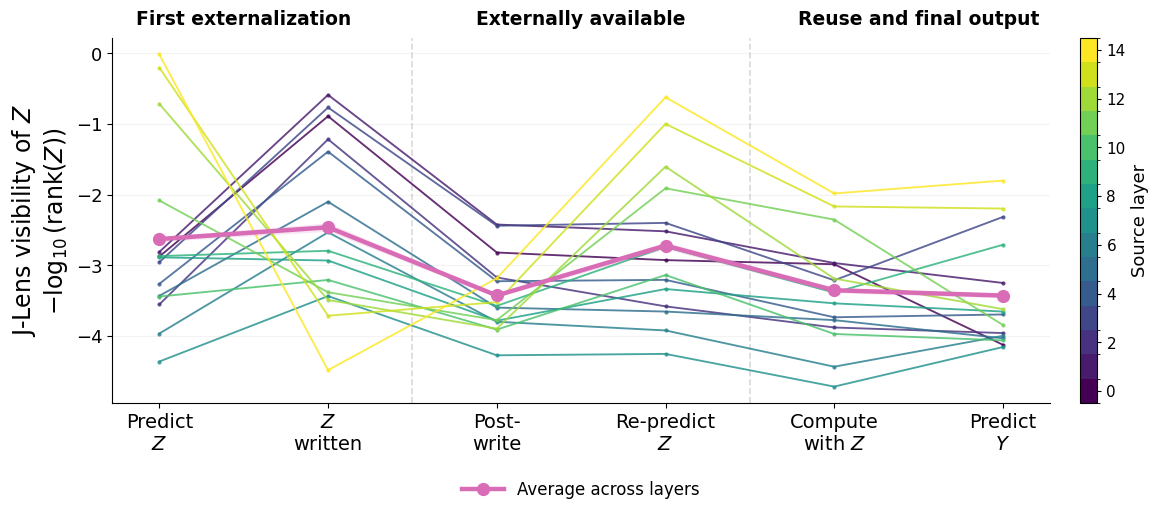

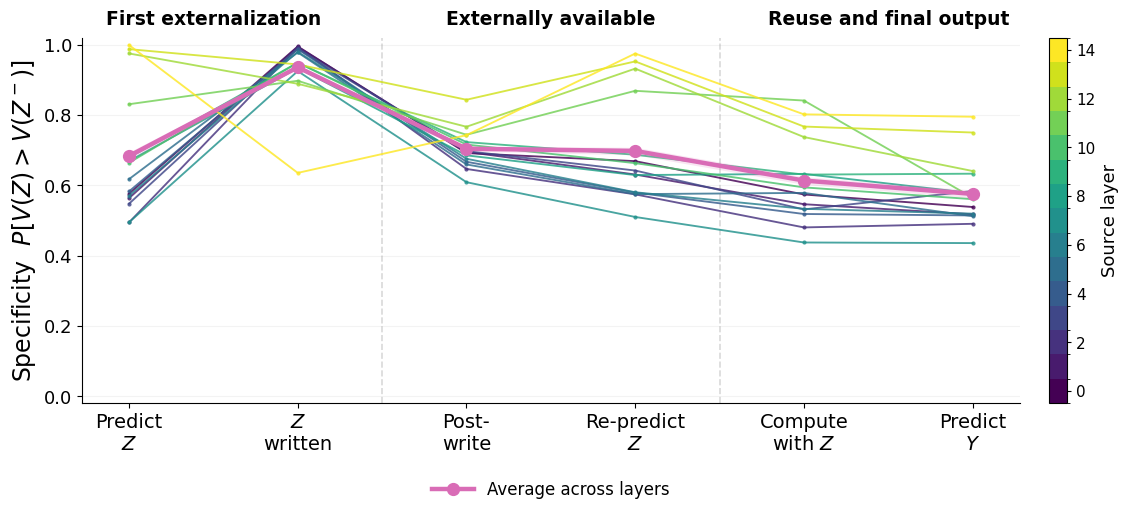

,event,n,mean,low,high
0,Predict Z,616,-2.6294,-2.6646,-2.5928
1,Z written,616,-2.4624,-2.5186,-2.4021
2,Post-write,616,-3.4270,-3.4534,-3.4001
3,Re-predict Z,616,-2.7213,-2.7706,-2.6723
4,Compute with Z,616,-3.3536,-3.3890,-3.3161
5,Predict Y,616,-3.4286,-3.4615,-3.3947


,event,n,mean,low,high
0,Predict Z,616,0.6836,0.6728,0.6948
1,Z written,616,0.9362,0.9320,0.9406
2,Post-write,616,0.7044,0.6975,0.7113
3,Re-predict Z,616,0.6981,0.6869,0.7085
4,Compute with Z,616,0.6138,0.6028,0.6247
5,Predict Y,616,0.5757,0.5645,0.5868


,metric,contrast,n,delta,CI_low,CI_high
0,visibility,Predict Z -> Post-write,616,-0.7976,-0.8378,-0.7593
1,visibility,Post-write -> Re-predict Z,616,0.7056,0.6507,0.7629
2,visibility,Post-write -> Compute with Z,616,0.0734,0.0327,0.1162
3,specificity,Predict Z -> Post-write,616,0.0208,0.0083,0.0331
4,specificity,Post-write -> Re-predict Z,616,-0.0063,-0.0177,0.0043
5,specificity,Post-write -> Compute with Z,616,-0.0906,-0.1028,-0.0794


Computational-reuse control:


,metric,contrast,n,delta,CI_low,CI_high
0,visibility,Non-reuse compute -> Compute with Z,351,-0.018,-0.0715,0.0357
1,specificity,Non-reuse compute -> Compute with Z,351,0.016,0.0032,0.0290


In [31]:
"""Replace the entire old PLOT + PAIRED BOOTSTRAP block with this file.

Same wide line-plot style, one figure per metric:
  thin colored lines = one problem-averaged curve per source layer;
  thick pink line = equal-layer, equal-Z, equal-problem global mean;
  pink band = pointwise 95% problem-bootstrap CI of that global mean.

Run compute_lifecycle_layerwise.py first. This file requires the resulting
Z_lifecycle_problem_df and Z_lifecycle_layer_problem_df (or layer_obs_df).
It performs no model inference. Existing figure filenames are retained.
"""

from pathlib import Path
import warnings
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value.to_string(index=False) if isinstance(value, pd.DataFrame) else value)

EVENTS = ["Predict Z", "Z written", "Post-write", "Re-predict Z",
          "Compute with Z", "Predict Y"]
EVENT_LABELS = ["Predict\n$Z$", "$Z$\nwritten", "Post-\nwrite",
                "Re-predict\n$Z$", "Compute\nwith $Z$", "Predict\n$Y$"]
N_BOOT = 3000
BOOT_SEED = 42
SHOW_GLOBAL_CI = True
SHOW_PHASE_LABELS = True
MEAN_COLOR = "#D96CB6"
LAYER_CMAP = "viridis"

# Change this assignment only if your layer-wise table has another name.
LIFECYCLE_LAYER_DF = globals().get("Z_lifecycle_layer_problem_df")
if LIFECYCLE_LAYER_DF is None:
    LIFECYCLE_LAYER_DF = globals().get("Z_lifecycle_layer_obs_df")
if LIFECYCLE_LAYER_DF is None:
    raise ValueError("Run the new layer-wise computation block first. "
                     "Z_lifecycle_problem_df alone cannot recover per-layer curves.")

OUT = Path(OUT)
OUT.mkdir(parents=True, exist_ok=True)


def _bootstrap_columns(values, n_boot=N_BOOT, seed=BOOT_SEED):
    """Each row is a problem. Use the same resampled problems across columns."""
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        values = values[:, None]
    valid = np.isfinite(values)
    n = valid.sum(axis=0)
    clean = np.where(valid, values, 0.0)
    mean = np.divide(clean.sum(axis=0), n,
                     out=np.full(values.shape[1], np.nan), where=n > 0)
    low, high = np.full_like(mean, np.nan), np.full_like(mean, np.nan)
    if len(values) < 2:
        return mean, low, high, n
    rng = np.random.default_rng(seed)
    weights = rng.multinomial(len(values), np.full(len(values), 1 / len(values)), size=n_boot)
    denom = weights @ valid.astype(float)
    boot = np.divide(weights @ clean, denom,
                     out=np.full(denom.shape, np.nan), where=denom > 0)
    for j in np.flatnonzero(n >= 2):
        low[j], high[j] = np.nanpercentile(boot[:, j], [2.5, 97.5])
    return mean, low, high, n


def summarize_events(df, metric):
    """Mean and pointwise bootstrap CI; NOT the old 10--90% sample range."""
    if df.duplicated(["dataset_idx", "event"]).any():
        raise ValueError("Global input must have one row per problem/event.")
    wide = df.pivot(index="dataset_idx", columns="event", values=metric).reindex(columns=EVENTS)
    mean, low, high, n = _bootstrap_columns(wide.to_numpy(float))
    return pd.DataFrame({"event": EVENTS, "n": n,
                         "mean": mean, "low": low, "high": high})


def paired_bootstrap(df, event_a, event_b, metric, n_boot=N_BOOT, seed=BOOT_SEED):
    wide = (df.pivot(index="dataset_idx", columns="event", values=metric)
            .reindex(columns=[event_a, event_b]).dropna())
    diff = (wide[event_b] - wide[event_a]).to_numpy(float)
    mean, low, high, n = _bootstrap_columns(diff, n_boot=n_boot, seed=seed)
    return {"contrast": f"{event_a} -> {event_b}", "n": int(n[0]),
            "delta": mean[0], "CI_low": low[0], "CI_high": high[0]}


def _prepare_layer_means(layer_df, problem_df, metric):
    d = layer_df.copy()
    alias = {"visibility": "V_jlens", "specificity": "Spec_jlens"}[metric]
    if metric not in d and alias in d:
        d = d.rename(columns={alias: metric})
    required = {"dataset_idx", "layer", "event", metric}
    if not required.issubset(d.columns):
        raise ValueError("Layer-wise input needs columns: " + ", ".join(sorted(required)))
    d = d[d.event.isin(EVENTS)].copy()
    p = problem_df[problem_df.event.isin(EVENTS)].copy()
    if d.empty or p.empty:
        raise ValueError("No measurements for the six lifecycle events.")
    if d[list(required)].isna().any().any() or not np.isfinite(d[metric].to_numpy(float)).all():
        raise ValueError("Layer-wise measurements contain missing/nonfinite values.")
    identity = ["dataset_idx", "event"] + (["z_idx"] if "z_idx" in d else [])
    if d[identity].isna().any().any() or d.duplicated(identity + ["layer"]).any():
        raise ValueError("Expected one row per problem/Z/layer/event or problem/layer/event. "
                         "Average event-window states before plotting.")
    layers = sorted(d["layer"].unique())
    if not d.groupby(identity)["layer"].nunique().eq(len(layers)).all():
        raise ValueError("Missing layers: every problem/Z/event must use the same source layers.")
    # Z average within problem/layer/event, then equal problem weight.
    layer_problem = d.groupby(["dataset_idx", "layer", "event"], as_index=False)[metric].mean()
    reconstructed = layer_problem.groupby(["dataset_idx", "event"])[metric].mean().sort_index()
    if p.duplicated(["dataset_idx", "event"]).any():
        raise ValueError("Global input must have one row per problem/event.")
    provided = p.set_index(["dataset_idx", "event"])[metric].sort_index()
    if (not reconstructed.index.equals(provided.index)
            or not np.allclose(reconstructed.to_numpy(), provided.to_numpy(), atol=1e-6, rtol=1e-6)):
        raise ValueError("Global and layer-wise data disagree. Use the same run, layer set, "
                         "event windows, and eligible Z. Do not use rounded summary tables.")
    layer_means = (layer_problem.groupby(["layer", "event"])[metric].mean()
                   .unstack("event").reindex(index=layers, columns=EVENTS))
    return layer_means, layers


def plot_Z_lifecycle(df, metric="visibility", save=None, layer_df=None):
    if layer_df is None:
        layer_df = LIFECYCLE_LAYER_DF
    layer_means, layers = _prepare_layer_means(layer_df, df, metric)
    summary = summarize_events(df, metric)
    x = np.arange(len(EVENTS))

    with plt.rc_context({"pdf.fonttype": 42, "ps.fonttype": 42}):
        fig, ax = plt.subplots(figsize=(11.8, 5.8))
        # Discrete colorbar: each color corresponds to one evaluated source layer.
        cmap = plt.get_cmap(LAYER_CMAP, len(layers))
        norm = BoundaryNorm(np.arange(len(layers) + 1) - 0.5, len(layers))
        for j, layer in enumerate(layers):
            ax.plot(x, layer_means.loc[layer].to_numpy(float),
                    color=cmap(j), linewidth=1.35, alpha=0.82,
                    marker="o", markersize=3.0, markeredgewidth=0,
                    zorder=3)

        # Uncertainty of the GLOBAL mean over problems, not variation over layers.
        if SHOW_GLOBAL_CI:
            ax.fill_between(x, summary["low"].to_numpy(), summary["high"].to_numpy(),
                            color=MEAN_COLOR, alpha=0.17, linewidth=0, zorder=5)
        ax.plot(x, summary["mean"].to_numpy(), color=MEAN_COLOR,
                marker="o", markersize=8.5, linewidth=3.2,
                label="Average across layers", zorder=10)

        # Retain the original separators and broad visual layout.
        ax.axvline(1.5, linestyle="--", linewidth=1.2, color="0.5", alpha=0.30)
        ax.axvline(3.5, linestyle="--", linewidth=1.2, color="0.5", alpha=0.30)
        if SHOW_PHASE_LABELS:
            for xpos, label in [(0.5, "First externalization"),
                                (2.5, "Externally available"),
                                (4.5, "Reuse and final output")]:
                ax.text(xpos, 1.025, label, transform=ax.get_xaxis_transform(),
                        ha="center", va="bottom", fontsize=13.5, fontweight="semibold")

        ax.set_xticks(x)
        ax.set_xticklabels(EVENT_LABELS, fontsize=14)
        if metric == "visibility":
            ax.set_ylabel("J-Lens visibility of $Z$\n" +
                          r"$-\log_{10}(\mathrm{rank}(Z))$", fontsize=17)
        else:
            ax.set_ylabel(r"Specificity  $P[V(Z)>V(Z^-)]$", fontsize=17)
            ax.set_ylim(-0.02, 1.02)
        ax.tick_params(axis="y", labelsize=13)
        ax.grid(axis="y", alpha=0.14, linewidth=0.8)
        ax.set_axisbelow(True)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(-0.28, len(EVENTS) - 0.72)

        # Keep the mean legend outside the data area.
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17),
                  frameon=False, fontsize=12, handlelength=2.5)
        fig.subplots_adjust(left=0.10, right=0.895, bottom=0.25, top=0.88)
        cax = fig.add_axes([0.92, 0.25, 0.015, 0.63])
        ticks = np.unique(np.linspace(0, len(layers)-1, min(len(layers), 8)).round().astype(int))
        colorbar = fig.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax, ticks=ticks)
        colorbar.ax.set_yticklabels([str(layers[j]) for j in ticks])
        colorbar.ax.tick_params(labelsize=11, length=3)
        colorbar.set_label("Source layer", fontsize=13)

        if save:
            path = Path(save)
            path.parent.mkdir(parents=True, exist_ok=True)
            fig.savefig(path, dpi=300, bbox_inches="tight", pad_inches=0.04)
            if path.suffix.lower() != ".png":
                fig.savefig(path.with_suffix(".png"), dpi=300, bbox_inches="tight", pad_inches=0.04)
            summary.to_csv(path.with_name(path.stem + "_global_summary.csv"), index=False)
            layer_means.to_csv(path.with_name(path.stem + "_layer_means.csv"))
        plt.show()
    return summary


# Existing filenames and output variables are retained.
visibility_lifecycle = plot_Z_lifecycle(
    Z_lifecycle_problem_df, "visibility", OUT / "cot_Z_lifecycle_visibility.pdf")
specificity_lifecycle = plot_Z_lifecycle(
    Z_lifecycle_problem_df, "specificity", OUT / "cot_Z_lifecycle_specificity.pdf")
display(visibility_lifecycle.round(4))
display(specificity_lifecycle.round(4))

# Same paired problem-level tests as in the original block.
# A problem-level paired comparison does not automatically pair identical
# Z subsets when one event (especially the optional control) has missing Z.
contrasts = []
for metric in ["visibility", "specificity"]:
    for a, b in [("Predict Z", "Post-write"),
                 ("Post-write", "Re-predict Z"),
                 ("Post-write", "Compute with Z")]:
        result = paired_bootstrap(Z_lifecycle_problem_df, a, b, metric)
        result["metric"] = metric
        contrasts.append(result)
contrast_df = pd.DataFrame(contrasts)

control_results = []
for metric in ["visibility", "specificity"]:
    result = paired_bootstrap(Z_lifecycle_problem_df, "Non-reuse compute", "Compute with Z", metric)
    result["metric"] = metric
    control_results.append(result)
control_df = pd.DataFrame(control_results)
columns = ["metric", "contrast", "n", "delta", "CI_low", "CI_high"]
display(contrast_df[columns].round(4))
print("Computational-reuse control:")
display(control_df[columns].round(4))
if contrast_df["n"].lt(2).any() or control_df["n"].lt(2).any():
    warnings.warn("Some contrasts have fewer than two paired problems; their CIs are unavailable.")
contrast_df[columns].to_csv(OUT / "cot_Z_lifecycle_contrasts.csv", index=False)
control_df[columns].to_csv(OUT / "cot_Z_lifecycle_control.csv", index=False)
